### 1. Import thư viện và cấu hình môi trường

Ở bước này, chúng ta import các thư viện cần thiết cho toàn bộ pipeline dự báo.

Các thư viện chính bao gồm:
- `pandas`: xử lý dữ liệu dạng bảng.
- `numpy`: hỗ trợ tính toán số học.
- `matplotlib`: trực quan hóa dữ liệu.
- `sklearn.metrics`: dùng để đánh giá chất lượng mô hình bằng các chỉ số MAE, RMSE và R².
- `pathlib.Path`: quản lý đường dẫn file một cách an toàn, đặc biệt khi chạy trên Windows.

Biến `DATA_DIR` được dùng để chỉ đến thư mục chứa toàn bộ dataset sau khi clean. Việc gom toàn bộ đường dẫn vào một biến giúp notebook dễ chỉnh sửa và tránh lỗi khi di chuyển file sang máy khác.

`RANDOM_SEED` được thiết lập để đảm bảo kết quả có tính tái lập. Điều này có nghĩa là khi chạy lại notebook nhiều lần, mô hình sẽ cho kết quả ổn định hơn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "dataset"

print("Notebook folder:", BASE_DIR)
print("Dataset folder:", DATA_DIR)

assert DATA_DIR.exists(), f"Dataset folder not found: {DATA_DIR}"

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

Notebook folder: C:\Users\Louis\Downloads\datathon-2026-round-1
Dataset folder: C:\Users\Louis\Downloads\datathon-2026-round-1\dataset


### 2. Đọc dữ liệu đầu vào

Ở bước này, notebook đọc toàn bộ các file dữ liệu cần dùng cho pipeline dự báo.

Các nhóm dữ liệu chính gồm:

1. Dữ liệu mục tiêu:
- `sales.csv`: chứa Revenue và COGS theo ngày. Đây là bảng trung tâm để huấn luyện mô hình.

2. Dữ liệu khung dự báo:
- `sample_submission.csv`: chỉ dùng để lấy danh sách ngày cần dự báo.
- Notebook chỉ đọc cột `Date` để tránh sử dụng nhầm Revenue hoặc COGS có sẵn trong file mẫu.

3. Dữ liệu vận hành:
- `web_traffic.csv`: phản ánh mức độ truy cập website.
- `inventory.csv`: phản ánh tình trạng tồn kho và khả năng đáp ứng hàng hóa.

4. Dữ liệu giao dịch và hành vi:
- `orders.csv`: thông tin đơn hàng.
- `order_items.csv`: chi tiết sản phẩm trong đơn hàng.
- `promotions.csv`: thông tin chương trình khuyến mãi.
- `returns.csv`: thông tin hoàn/trả hàng.
- `reviews.csv`: thông tin đánh giá của khách hàng.

5. Datamart bổ sung:
- `leakage_datamart.csv`: mô tả các đơn hàng có khả năng gây thất thoát.
- `profit_datamart.csv`: mô tả các đơn hàng mang lại doanh thu, COGS và lợi nhuận.

Mục tiêu của bước này là đưa tất cả nguồn dữ liệu cần thiết vào notebook để phục vụ tạo feature, huấn luyện mô hình và tạo file dự báo cuối cùng.

In [2]:
sales = pd.read_csv(DATA_DIR / "sales.csv", parse_dates=["Date"])

sample = pd.read_csv(
    DATA_DIR / "sample_submission.csv",
    usecols=["Date"],
    parse_dates=["Date"]
)

traffic = pd.read_csv(DATA_DIR / "web_traffic.csv", parse_dates=["date"])
inventory = pd.read_csv(DATA_DIR / "inventory.csv", parse_dates=["snapshot_date"])

orders = pd.read_csv(DATA_DIR / "orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv(DATA_DIR / "order_items.csv", low_memory=False)

promotions = pd.read_csv(
    DATA_DIR / "promotions.csv",
    parse_dates=["start_date", "end_date"]
)

returns = pd.read_csv(DATA_DIR / "returns.csv", parse_dates=["return_date"])
reviews = pd.read_csv(DATA_DIR / "reviews.csv", parse_dates=["review_date"])

leakage_dm = pd.read_csv(DATA_DIR / "leakage_datamart.csv", low_memory=False)
profit_dm = pd.read_csv(DATA_DIR / "profit_datamart.csv", low_memory=False)

print("sales:", sales.shape)
print("sample:", sample.shape)
print("traffic:", traffic.shape)
print("inventory:", inventory.shape)
print("orders:", orders.shape)
print("order_items:", order_items.shape)
print("promotions:", promotions.shape)
print("returns:", returns.shape)
print("reviews:", reviews.shape)
print("leakage_dm:", leakage_dm.shape)
print("profit_dm:", profit_dm.shape)

sales.head()

sales: (3833, 3)
sample: (548, 1)
traffic: (3652, 7)
inventory: (60247, 14)
orders: (646945, 8)
order_items: (714669, 7)
promotions: (50, 10)
returns: (39939, 7)
reviews: (113551, 7)
leakage_dm: (105711, 18)
profit_dm: (626007, 26)


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


### 3. Kiểm tra cấu trúc dữ liệu ban đầu

Sau khi đọc dữ liệu, cần kiểm tra nhanh cấu trúc của bảng `sales`, vì đây là bảng trung tâm của bài toán dự báo.

Các thao tác kiểm tra gồm:
- `info()`: xem kiểu dữ liệu và số lượng giá trị không null.
- `describe()`: xem các thống kê cơ bản như mean, min, max, quartile.
- `isnull().sum()`: kiểm tra số lượng giá trị thiếu.

Mục tiêu của bước này là đảm bảo dữ liệu Revenue và COGS có định dạng hợp lệ trước khi xây dựng mô hình. Nếu dữ liệu đầu vào sai hoặc thiếu nghiêm trọng, các bước feature engineering và modeling phía sau có thể bị sai lệch.




In [3]:
print(sales.info())
print(sales.describe())
print(sales.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     3833 non-null   datetime64[ns]
 1   Revenue  3833 non-null   float64       
 2   COGS     3833 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 90.0 KB
None
                      Date       Revenue          COGS
count                 3833  3.833000e+03  3.833000e+03
mean   2017-10-02 00:00:00  4.286584e+06  3.695134e+06
min    2012-07-04 00:00:00  2.798139e+05  2.365763e+05
25%    2015-02-17 00:00:00  2.471089e+06  2.150580e+06
50%    2017-10-02 00:00:00  3.647304e+06  3.161113e+06
75%    2020-05-17 00:00:00  5.350877e+06  4.637294e+06
max    2022-12-31 00:00:00  2.090527e+07  1.653586e+07
std                    NaN  2.624840e+06  2.219789e+06
Date       0
Revenue    0
COGS       0
dtype: int64


### 4. Quan sát chuỗi thời gian Revenue

Biểu đồ này thể hiện Revenue theo ngày trong giai đoạn lịch sử.

Mục tiêu của bước trực quan hóa là giúp nhận diện:
- Xu hướng tăng hoặc giảm dài hạn.
- Tính mùa vụ theo tuần, tháng hoặc năm.
- Các ngày có doanh thu tăng đột biến.
- Các giai đoạn biến động bất thường.

Đây là bước quan trọng trong bài toán forecasting, vì trước khi xây dựng mô hình, ta cần hiểu dữ liệu có pattern theo thời gian hay không.

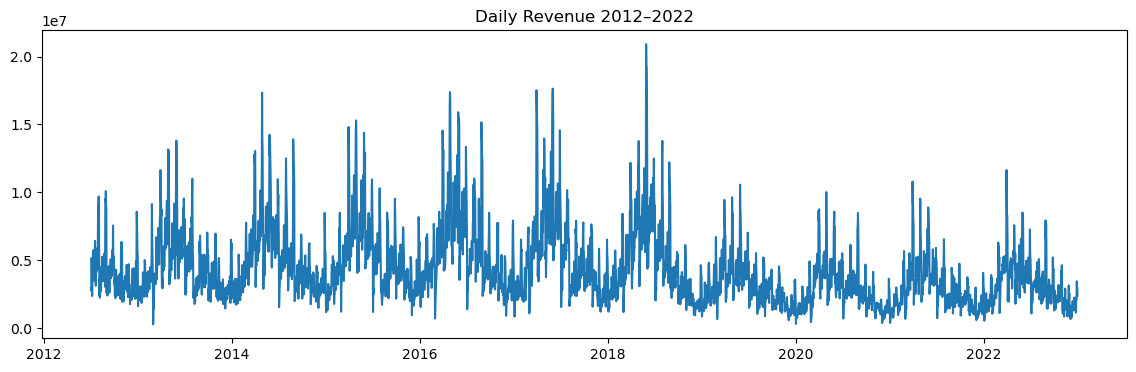

In [4]:

plt.figure(figsize=(14,4))
plt.plot(sales["Date"], sales["Revenue"])
plt.title("Daily Revenue 2012–2022")
plt.show()

### 5. Tạo đặc trưng thời gian nâng cao

Từ cột `Date`, bước này tạo ra các đặc trưng thời gian để mô hình học được các quy luật lặp lại theo lịch.

Các feature cơ bản:
- `year`: năm.
- `month`: tháng.
- `day`: ngày trong tháng.
- `day_of_week`: thứ trong tuần.
- `is_weekend`: đánh dấu cuối tuần.
- `quarter`: quý.
- `day_of_year`: ngày thứ bao nhiêu trong năm.
- `week_of_year`: tuần thứ bao nhiêu trong năm.
- `is_month_start`: có phải đầu tháng không.
- `is_month_end`: có phải cuối tháng không.

Ngoài ra, các biến chu kỳ như `month_sin`, `month_cos`, `dow_sin`, `dow_cos`, `doy_sin`, `doy_cos` được tạo để giúp mô hình hiểu rằng thời gian có tính vòng lặp. Ví dụ: tháng 12 và tháng 1 thực chất gần nhau theo chu kỳ năm, dù giá trị số học 12 và 1 cách xa nhau.

Nhóm feature này giúp mô hình nắm bắt seasonality tốt hơn.

In [5]:
def add_calendar_features(df):
    df = df.copy()
    df["year"] = df["Date"].dt.year
    df["month"] = df["Date"].dt.month
    df["day"] = df["Date"].dt.day
    df["day_of_week"] = df["Date"].dt.dayofweek
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    df["quarter"] = df["Date"].dt.quarter
    df["day_of_year"] = df["Date"].dt.dayofyear
    df["week_of_year"] = df["Date"].dt.isocalendar().week.astype(int)
    df["is_month_start"] = df["Date"].dt.is_month_start.astype(int)
    df["is_month_end"] = df["Date"].dt.is_month_end.astype(int)

    # Cyclical encoding: giúp model hiểu tháng/ngày trong tuần có tính chu kỳ
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
    df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
    df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)

    return df

sales = add_calendar_features(sales)
sample = add_calendar_features(sample)

### 5.1. Tạo đặc trưng lịch khuyến mãi

Bước này chuyển bảng `promotions` thành các đặc trưng khuyến mãi theo từng ngày.

Các thông tin được tạo gồm:
- Số lượng khuyến mãi đang hoạt động trong ngày.
- Mức giảm giá trung bình và lớn nhất.
- Số lượng khuyến mãi có thể áp dụng chồng.
- Giá trị đơn hàng tối thiểu trung bình.

Với dữ liệu lịch sử, các đặc trưng này được merge trực tiếp vào bảng `sales` theo `Date`. Với tập test, vì không có lịch khuyến mãi tương lai chi tiết, notebook tạo pattern khuyến mãi theo `month` và `day`, sau đó gắn pattern này vào các ngày cần dự báo.

Mục tiêu là giúp mô hình nhận biết những thời điểm trong năm thường có tác động từ promotion.

In [6]:
# Tạo bảng promotion theo từng ngày
promo_rows = []

for _, row in promotions.iterrows():
    promo_dates = pd.date_range(row["start_date"], row["end_date"], freq="D")

    for d in promo_dates:
        promo_rows.append({
            "Date": d,
            "active_promo_count": 1,
            "promo_discount_mean": row["discount_value"],
            "promo_discount_max": row["discount_value"],
            "promo_stackable_count": row["stackable_flag"],
            "promo_min_order_mean": row["min_order_value"]
        })

promo_daily = pd.DataFrame(promo_rows)

promo_daily = (
    promo_daily
    .groupby("Date")
    .agg({
        "active_promo_count": "sum",
        "promo_discount_mean": "mean",
        "promo_discount_max": "max",
        "promo_stackable_count": "sum",
        "promo_min_order_mean": "mean"
    })
    .reset_index()
)

# Merge vào sales
sales = sales.merge(promo_daily, on="Date", how="left")

promo_cols = [
    "active_promo_count",
    "promo_discount_mean",
    "promo_discount_max",
    "promo_stackable_count",
    "promo_min_order_mean"
]

for col in promo_cols:
    sales[col] = sales[col].fillna(0)

# Với test, không có lịch promo tương lai nên dùng pattern lịch sử theo month + day
promo_pattern = (
    sales
    .groupby(["month", "day"])[promo_cols]
    .mean()
    .reset_index()
)

sample = sample.merge(promo_pattern, on=["month", "day"], how="left")

for col in promo_cols:
    sample[col] = sample[col].fillna(0)

sales[promo_cols].head()

,active_promo_count,promo_discount_mean,promo_discount_max,promo_stackable_count,promo_min_order_mean
0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0


### 6. Tổng hợp dữ liệu web traffic theo ngày

Dữ liệu web traffic có thể có nhiều dòng cho cùng một ngày, phân theo traffic source. Vì mô hình dự báo Revenue theo ngày, dữ liệu traffic cũng cần được đưa về cấp độ ngày.

Cách tổng hợp:
- Các biến số lượng như `sessions`, `unique_visitors`, `page_views` được cộng lại.
- Các biến tỷ lệ hoặc trung bình như `bounce_rate`, `avg_session_duration_sec` được lấy trung bình.

Ý nghĩa kinh doanh:
- Traffic cao thường phản ánh nhu cầu cao hơn.
- Page views cao có thể cho thấy khách hàng quan tâm nhiều sản phẩm hơn.
- Bounce rate cao có thể phản ánh chất lượng traffic thấp hơn.

Sau khi tổng hợp, dữ liệu traffic được merge vào bảng lịch sử theo `Date`. Với tập test, các giá trị traffic sẽ được điều chỉnh ở bước tiếp theo bằng pattern lịch sử theo `month` và `day`.

In [7]:
traffic_daily = (
    traffic
    .groupby("date")
    .agg({
        "sessions": "sum",
        "unique_visitors": "sum",
        "page_views": "sum",
        "bounce_rate": "mean",
        "avg_session_duration_sec": "mean"
    })
    .reset_index()
    .rename(columns={"date": "Date"})
)

sales = sales.merge(traffic_daily, on="Date", how="left")
sample = sample.merge(traffic_daily, on="Date", how="left")

### 7. Kết hợp và ước lượng web traffic cho tập test

Tập test là giai đoạn tương lai nên không phải lúc nào cũng có dữ liệu traffic thực tế. Vì vậy, bước này tạo traffic pattern lịch sử theo `month` và `day`, sau đó dùng pattern đó để ước lượng traffic cho các ngày trong test.

Cách làm:
- Tính trung bình các biến traffic theo từng cặp `month` và `day`.
- Merge pattern này vào tập test.
- Fill missing bằng median của tập train nếu vẫn còn thiếu.

Cách này không dùng dữ liệu ngoài và không nhìn thấy tương lai. Nó chỉ dùng pattern lịch sử để mô phỏng hành vi traffic cho ngày tương lai.

In [8]:
traffic_cols = [
    "sessions",
    "unique_visitors",
    "page_views",
    "bounce_rate",
    "avg_session_duration_sec"
]

traffic_pattern = (
    sales
    .groupby(["month", "day"])[traffic_cols]
    .mean()
    .reset_index()
)

sample = sample.drop(columns=[c for c in traffic_cols if c in sample.columns])
sample = sample.merge(traffic_pattern, on=["month", "day"], how="left")

for col in traffic_cols:
    sales[col] = sales[col].fillna(sales[col].median())
    sample[col] = sample[col].fillna(sales[col].median())

### 7.1. Tạo đặc trưng mở rộng từ web traffic

Sau khi có các chỉ số traffic cơ bản, bước này tạo thêm các biến phản ánh chất lượng traffic.

Các feature được tạo gồm:
- `pageviews_per_session`: số page view trung bình trên mỗi session.
- `sessions_per_visitor`: số session trung bình trên mỗi visitor.
- `traffic_engagement`: kết hợp giữa độ sâu truy cập và thời gian phiên.
- `bounce_sessions`: ước lượng số session có khả năng thoát nhanh.

Ý nghĩa:
Không chỉ số lượng người truy cập quan trọng, mà chất lượng truy cập cũng ảnh hưởng đến doanh thu. Ví dụ, nhiều session nhưng bounce rate cao có thể không chuyển đổi thành doanh thu tốt.

In [9]:
def add_traffic_derived_features(df):
    df = df.copy()
    df["pageviews_per_session"] = df["page_views"] / (df["sessions"] + 1)
    df["sessions_per_visitor"] = df["sessions"] / (df["unique_visitors"] + 1)
    df["traffic_engagement"] = df["pageviews_per_session"] * df["avg_session_duration_sec"]
    df["bounce_sessions"] = df["bounce_rate"] * df["sessions"]
    return df

sales = add_traffic_derived_features(sales)
sample = add_traffic_derived_features(sample)

### 7.2. Tạo đặc trưng hành vi giao dịch theo ngày

Bước này kết hợp `orders` và `order_items` để tạo các chỉ số giao dịch theo ngày, ví dụ:
- Số lượng đơn hàng.
- Số khách hàng duy nhất.
- Tổng số lượng sản phẩm bán ra.
- Tổng giá trị đơn hàng trước và sau discount.
- Tổng discount.
- Tỷ lệ dòng sản phẩm có sử dụng promotion.

Các đặc trưng này giúp kiểm tra cường độ giao dịch trong lịch sử. Trong pipeline dự báo chính, các tín hiệu giao dịch được khai thác sâu hơn ở nhóm business pattern theo `month` và `day`.

In [10]:
# Join orders với order_items để tạo transaction features theo ngày
order_items_clean = order_items.copy()

# promo_id có thể bị thiếu, chuyển thành flag
order_items_clean["has_promo"] = (
    order_items_clean["promo_id"].notna() | order_items_clean["promo_id_2"].notna()
).astype(int)

order_items_clean["item_gross_value"] = (
    order_items_clean["quantity"] * order_items_clean["unit_price"]
)

order_items_clean["item_net_value"] = (
    order_items_clean["item_gross_value"] - order_items_clean["discount_amount"]
)

order_txn = order_items_clean.merge(
    orders[["order_id", "order_date", "customer_id", "order_status", "device_type", "order_source"]],
    on="order_id",
    how="left"
)

txn_daily = (
    order_txn
    .groupby("order_date")
    .agg({
        "order_id": "nunique",
        "customer_id": "nunique",
        "quantity": "sum",
        "item_gross_value": "sum",
        "item_net_value": "sum",
        "discount_amount": "sum",
        "has_promo": "mean"
    })
    .reset_index()
    .rename(columns={
        "order_date": "Date",
        "order_id": "daily_order_count",
        "customer_id": "daily_unique_customers",
        "quantity": "daily_quantity_sold",
        "item_gross_value": "daily_gross_value",
        "item_net_value": "daily_net_value",
        "discount_amount": "daily_discount_amount",
        "has_promo": "daily_promo_item_ratio"
    })
)

txn_daily["daily_avg_order_value"] = (
    txn_daily["daily_net_value"] / (txn_daily["daily_order_count"] + 1)
)

txn_daily["daily_discount_rate"] = (
    txn_daily["daily_discount_amount"] / (txn_daily["daily_gross_value"] + 1)
)

txn_cols = [
    "daily_order_count",
    "daily_unique_customers",
    "daily_quantity_sold",
    "daily_gross_value",
    "daily_net_value",
    "daily_discount_amount",
    "daily_promo_item_ratio",
    "daily_avg_order_value",
    "daily_discount_rate"
]

# Merge vào sales
sales = sales.merge(txn_daily, on="Date", how="left")

for col in txn_cols:
    sales[col] = sales[col].fillna(0)

# Với test, dùng pattern lịch sử theo month + day
txn_pattern = (
    sales
    .groupby(["month", "day"])[txn_cols]
    .mean()
    .reset_index()
)

sample = sample.merge(txn_pattern, on=["month", "day"], how="left")

for col in txn_cols:
    sample[col] = sample[col].fillna(sales[col].median())

sales[txn_cols].head()

,daily_order_count,daily_unique_customers,daily_quantity_sold,daily_gross_value,daily_net_value,daily_discount_amount,daily_promo_item_ratio,daily_avg_order_value,daily_discount_rate
0,162,161,777,5123547.94,5123547.94,0.0,0.0,31432.809448,0.0
1,97,97,428,2751773.45,2751773.45,0.0,0.0,28079.320918,0.0
2,93,93,441,3054029.42,3054029.42,0.0,0.0,32489.674681,0.0
3,73,73,364,2667930.94,2667930.94,0.0,0.0,36053.120811,0.0
4,88,87,394,2360851.90,2360851.90,0.0,0.0,26526.425843,0.0


### 8. Tổng hợp dữ liệu inventory theo tháng

Dữ liệu inventory thể hiện tình trạng tồn kho theo sản phẩm và theo thời điểm snapshot. Vì Revenue được dự báo theo ngày, nhưng inventory thường có tính chất chậm hơn và được ghi nhận theo tháng, bước này tổng hợp inventory về cấp độ `year` và `month`.

Các chỉ số được tổng hợp gồm:
- `stock_on_hand`: tổng lượng hàng tồn.
- `units_received`: tổng hàng nhập.
- `units_sold`: tổng hàng bán.
- `days_of_supply`: số ngày tồn kho trung bình.
- `fill_rate`: khả năng đáp ứng nhu cầu.
- `reorder_flag`: tín hiệu cần nhập thêm hàng.
- `sell_through_rate`: tốc độ bán hàng.

 Nếu file inventory còn chứa các cột như `stockout_days`, `stockout_flag` hoặc `overstock_flag`, notebook sẽ tự động sử dụng thêm các cột này. Nếu các cột đó đã bị loại bỏ trong bản clean, code sẽ bỏ qua để tránh lỗi schema.

Ý nghĩa kinh doanh:
Doanh thu không chỉ phụ thuộc vào nhu cầu, mà còn phụ thuộc vào khả năng cung ứng. Nếu hàng tồn không đủ hoặc tỷ lệ đáp ứng thấp, doanh thu có thể bị giới hạn.



In [11]:
inventory["year"] = inventory["snapshot_date"].dt.year
inventory["month"] = inventory["snapshot_date"].dt.month

inventory_agg_dict = {
    "stock_on_hand": "sum",
    "units_received": "sum",
    "units_sold": "sum",
    "days_of_supply": "mean",
    "fill_rate": "mean",
    "reorder_flag": "max",
    "sell_through_rate": "mean"
}

# Chỉ dùng nếu cột còn tồn tại trong file clean
optional_inventory_cols = {
    "stockout_days": "sum",
    "stockout_flag": "max",
    "overstock_flag": "max"
}

for col, agg_func in optional_inventory_cols.items():
    if col in inventory.columns:
        inventory_agg_dict[col] = agg_func

inventory_monthly = (
    inventory
    .groupby(["year", "month"])
    .agg(inventory_agg_dict)
    .reset_index()
)

sales = sales.merge(inventory_monthly, on=["year", "month"], how="left")
sample = sample.merge(inventory_monthly, on=["year", "month"], how="left")

print(inventory_monthly.columns.tolist())

['year', 'month', 'stock_on_hand', 'units_received', 'units_sold', 'days_of_supply', 'fill_rate', 'reorder_flag', 'sell_through_rate']


### 9. Kết hợp và ước lượng inventory cho tập test

Tập test là tương lai nên không có đầy đủ inventory thực tế. Vì vậy, bước này tạo pattern inventory theo tháng từ dữ liệu lịch sử rồi áp dụng cho test.

Cách làm:
- Tính trung bình các biến inventory theo `month`.
- Merge pattern này vào tập test.
- Fill missing bằng median của tập train.

Bước này giúp mô hình có thêm thông tin về supply-side mà không sử dụng dữ liệu tương lai thực tế. Đây là cách xử lý an toàn trong bài toán forecasting.

In [12]:
inventory_cols = [
    "stock_on_hand",
    "units_received",
    "units_sold",
    "days_of_supply",
    "fill_rate",
    "reorder_flag",
    "sell_through_rate"
]

# Thêm nếu các cột này vẫn còn trong inventory clean
optional_cols = [
    "stockout_days",
    "stockout_flag",
    "overstock_flag"
]

for col in optional_cols:
    if col in sales.columns:
        inventory_cols.append(col)

inventory_pattern = (
    sales
    .groupby("month")[inventory_cols]
    .mean()
    .reset_index()
)

sample = sample.drop(columns=[c for c in inventory_cols if c in sample.columns])
sample = sample.merge(inventory_pattern, on="month", how="left")

for col in inventory_cols:
    sales[col] = sales[col].fillna(sales[col].median())
    sample[col] = sample[col].fillna(sales[col].median())

print("inventory_cols:", inventory_cols)

inventory_cols: ['stock_on_hand', 'units_received', 'units_sold', 'days_of_supply', 'fill_rate', 'reorder_flag', 'sell_through_rate']


### 9.1. Tạo đặc trưng mở rộng từ inventory

Bước này tạo thêm các feature từ dữ liệu inventory để mô hình hiểu sâu hơn về trạng thái nguồn cung.

Các feature chính gồm:
- `supply_efficiency`: kết hợp giữa fill rate và sell-through rate, phản ánh hiệu quả cung ứng.
- `inventory_turnover_proxy`: xấp xỉ tốc độ quay vòng hàng tồn.
- `received_to_stock_ratio`: tỷ lệ hàng nhập so với lượng hàng tồn.
- `stockout_pressure`: áp lực hết hàng, chỉ được tạo khi dữ liệu còn đủ `stockout_days` và `stockout_flag`.

Nếu dữ liệu clean không còn các cột stockout, notebook tự gán `stockout_pressure = 0` để đảm bảo pipeline vẫn chạy ổn định.

Nhóm feature này giúp mô hình xem xét yếu tố nguồn cung, thay vì chỉ dựa vào nhu cầu hoặc doanh thu quá khứ.

In [13]:
def add_inventory_derived_features(df):
    df = df.copy()

    df["supply_efficiency"] = df["fill_rate"] * df["sell_through_rate"]
    df["inventory_turnover_proxy"] = df["units_sold"] / (df["stock_on_hand"] + 1)
    df["received_to_stock_ratio"] = df["units_received"] / (df["stock_on_hand"] + 1)

    # Chỉ tạo stockout_pressure nếu schema còn đủ cột
    if ("stockout_days" in df.columns) and ("stockout_flag" in df.columns):
        df["stockout_pressure"] = df["stockout_days"] * df["stockout_flag"]
    else:
        df["stockout_pressure"] = 0

    return df

sales = add_inventory_derived_features(sales)
sample = add_inventory_derived_features(sample)

### 9.2. Tạo business pattern features từ transaction, promotion, return và review

Bước này tạo các đặc trưng phản ánh hành vi kinh doanh từ nhiều bảng dữ liệu khác nhau.

Nguồn dữ liệu sử dụng:
- `orders`: số đơn, số khách, thiết bị đặt hàng, nguồn đơn hàng và phương thức thanh toán.
- `order_items`: số lượng sản phẩm, đơn giá, discount và tỷ lệ sử dụng promotion.
- `promotions`: số lượng khuyến mãi, mức giảm giá và loại khuyến mãi.
- `returns`: số đơn hoàn/trả, số lượng trả và refund.
- `reviews`: số lượng đánh giá, rating trung bình và tỷ lệ rating cao/thấp.

Vì tập test không có giao dịch thực tế trong tương lai, các tín hiệu này được tổng hợp thành pattern lịch sử theo `month` và `day`, sau đó áp dụng cho cả dữ liệu lịch sử và dữ liệu cần dự báo.

Mục tiêu là giúp mô hình học các quy luật kinh doanh lặp lại theo mùa vụ, thay vì chỉ dựa vào đặc trưng thời gian và Revenue quá khứ.

In [14]:
# =========================================================
# 9.2 Business pattern features
# =========================================================

# Mục tiêu:
# - Tạo các feature phản ánh order behavior, discount, promotion, return và review pattern
# - Dùng pattern lịch sử theo month/day để áp dụng cho cả train và test
# - Tránh xung đột cột khi chạy lại cell nhiều lần


# ---------------------------------------------------------
# Helper: xóa các cột đã tồn tại để tránh merge ra _x, _y
# ---------------------------------------------------------

def drop_existing_columns(df, cols):
    existing_cols = [c for c in cols if c in df.columns]
    if existing_cols:
        df = df.drop(columns=existing_cols)
    return df


# ---------------------------------------------------------
# Khai báo trước toàn bộ tên cột business để tránh conflict
# ---------------------------------------------------------

order_pattern_cols = [
    "order_count",
    "customer_count",
    "mobile_order_ratio",
    "desktop_order_ratio",
    "paid_search_ratio",
    "direct_ratio",
    "email_campaign_ratio",
    "cod_ratio",
    "credit_card_ratio"
]

item_pattern_cols = [
    "avg_quantity",
    "total_quantity",
    "avg_unit_price",
    "avg_discount_amount",
    "avg_discount_rate",
    "promo_line_ratio",
    "gross_item_value",
    "net_item_value"
]

promo_pattern_cols = [
    "promo_active_count",
    "promo_discount_value_mean",
    "promo_discount_value_max",
    "promo_stackable_count",
    "promo_min_order_value_mean",
    "promo_percentage_count",
    "promo_fixed_count"
]

return_pattern_cols = [
    "return_count",
    "return_quantity_sum",
    "refund_amount_sum"
]

review_pattern_cols = [
    "review_count",
    "avg_rating",
    "low_rating_ratio",
    "high_rating_ratio"
]

business_pattern_cols = (
    order_pattern_cols
    + item_pattern_cols
    + promo_pattern_cols
    + return_pattern_cols
    + review_pattern_cols
)

# Xóa cột business cũ nếu cell này từng được chạy trước đó
sales = drop_existing_columns(sales, business_pattern_cols)
sample = drop_existing_columns(sample, business_pattern_cols)


# =========================================================
# 1. Order behavior pattern
# =========================================================

orders_tmp = orders.copy()
orders_tmp["Date"] = orders_tmp["order_date"].dt.normalize()

order_daily = (
    orders_tmp
    .groupby("Date")
    .agg(
        order_count=("order_id", "nunique"),
        customer_count=("customer_id", "nunique"),
        mobile_order_ratio=("device_type", lambda x: (x == "mobile").mean()),
        desktop_order_ratio=("device_type", lambda x: (x == "desktop").mean()),
        paid_search_ratio=("order_source", lambda x: (x == "paid_search").mean()),
        direct_ratio=("order_source", lambda x: (x == "direct").mean()),
        email_campaign_ratio=("order_source", lambda x: (x == "email_campaign").mean()),
        cod_ratio=("payment_method", lambda x: (x == "cod").mean()),
        credit_card_ratio=("payment_method", lambda x: (x == "credit_card").mean())
    )
    .reset_index()
)

order_daily = add_calendar_features(order_daily)

order_pattern = (
    order_daily
    .groupby(["month", "day"], as_index=False)[order_pattern_cols]
    .mean()
)

sales = sales.merge(order_pattern, on=["month", "day"], how="left")
sample = sample.merge(order_pattern, on=["month", "day"], how="left")


# =========================================================
# 2. Order item / discount pattern
# =========================================================

items_tmp = order_items.copy()

items_tmp = items_tmp.merge(
    orders[["order_id", "order_date"]],
    on="order_id",
    how="left"
)

items_tmp["Date"] = items_tmp["order_date"].dt.normalize()

items_tmp["gross_line_value"] = items_tmp["quantity"] * items_tmp["unit_price"]
items_tmp["net_line_value"] = items_tmp["gross_line_value"] - items_tmp["discount_amount"]
items_tmp["discount_rate"] = items_tmp["discount_amount"] / (items_tmp["gross_line_value"] + 1)

items_tmp["has_promo"] = (
    items_tmp["promo_id"].notna() | items_tmp["promo_id_2"].notna()
).astype(int)

item_daily = (
    items_tmp
    .groupby("Date")
    .agg(
        avg_quantity=("quantity", "mean"),
        total_quantity=("quantity", "sum"),
        avg_unit_price=("unit_price", "mean"),
        avg_discount_amount=("discount_amount", "mean"),
        avg_discount_rate=("discount_rate", "mean"),
        promo_line_ratio=("has_promo", "mean"),
        gross_item_value=("gross_line_value", "sum"),
        net_item_value=("net_line_value", "sum")
    )
    .reset_index()
)

item_daily = add_calendar_features(item_daily)

item_pattern = (
    item_daily
    .groupby(["month", "day"], as_index=False)[item_pattern_cols]
    .mean()
)

sales = sales.merge(item_pattern, on=["month", "day"], how="left")
sample = sample.merge(item_pattern, on=["month", "day"], how="left")


# =========================================================
# 3. Promotion calendar pattern
# =========================================================

promo_rows = []

for _, row in promotions.iterrows():
    promo_dates = pd.date_range(row["start_date"], row["end_date"], freq="D")

    temp = pd.DataFrame({
        "Date": promo_dates,
        "promo_active": 1,
        "promo_discount_value": row["discount_value"],
        "promo_stackable_flag": row["stackable_flag"],
        "promo_min_order_value": row["min_order_value"],
        "promo_is_percentage": int(row["promo_type"] == "percentage"),
        "promo_is_fixed": int(row["promo_type"] == "fixed")
    })

    promo_rows.append(temp)

if len(promo_rows) > 0:
    promo_daily_raw = pd.concat(promo_rows, ignore_index=True)

    promo_daily = (
        promo_daily_raw
        .groupby("Date")
        .agg(
            promo_active_count=("promo_active", "sum"),
            promo_discount_value_mean=("promo_discount_value", "mean"),
            promo_discount_value_max=("promo_discount_value", "max"),
            promo_stackable_count=("promo_stackable_flag", "sum"),
            promo_min_order_value_mean=("promo_min_order_value", "mean"),
            promo_percentage_count=("promo_is_percentage", "sum"),
            promo_fixed_count=("promo_is_fixed", "sum")
        )
        .reset_index()
    )

    promo_daily = add_calendar_features(promo_daily)

    promo_pattern = (
        promo_daily
        .groupby(["month", "day"], as_index=False)[promo_pattern_cols]
        .mean()
    )
else:
    promo_pattern = pd.DataFrame(columns=["month", "day"] + promo_pattern_cols)

sales = sales.merge(promo_pattern, on=["month", "day"], how="left")
sample = sample.merge(promo_pattern, on=["month", "day"], how="left")


# =========================================================
# 4. Return pattern
# =========================================================

returns_tmp = returns.copy()
returns_tmp["Date"] = returns_tmp["return_date"].dt.normalize()

return_daily = (
    returns_tmp
    .groupby("Date")
    .agg(
        return_count=("return_id", "nunique"),
        return_quantity_sum=("return_quantity", "sum"),
        refund_amount_sum=("refund_amount", "sum")
    )
    .reset_index()
)

return_daily = add_calendar_features(return_daily)

return_pattern = (
    return_daily
    .groupby(["month", "day"], as_index=False)[return_pattern_cols]
    .mean()
)

sales = sales.merge(return_pattern, on=["month", "day"], how="left")
sample = sample.merge(return_pattern, on=["month", "day"], how="left")


# =========================================================
# 5. Review pattern
# =========================================================

reviews_tmp = reviews.copy()
reviews_tmp["Date"] = reviews_tmp["review_date"].dt.normalize()

review_daily = (
    reviews_tmp
    .groupby("Date")
    .agg(
        review_count=("review_id", "nunique"),
        avg_rating=("rating", "mean"),
        low_rating_ratio=("rating", lambda x: (x <= 2).mean()),
        high_rating_ratio=("rating", lambda x: (x >= 4).mean())
    )
    .reset_index()
)

review_daily = add_calendar_features(review_daily)

review_pattern = (
    review_daily
    .groupby(["month", "day"], as_index=False)[review_pattern_cols]
    .mean()
)

sales = sales.merge(review_pattern, on=["month", "day"], how="left")
sample = sample.merge(review_pattern, on=["month", "day"], how="left")


# =========================================================
# 6. Fill missing values
# =========================================================

for col in business_pattern_cols:
    sales[col] = sales[col].fillna(sales[col].median())
    sample[col] = sample[col].fillna(sales[col].median())


# =========================================================
# 7. Kiểm tra sau khi tạo feature
# =========================================================

print("Business pattern features added:", len(business_pattern_cols))
print("Duplicated columns in sales:", sales.columns[sales.columns.duplicated()].tolist())
print("Duplicated columns in sample:", sample.columns[sample.columns.duplicated()].tolist())

print("Sales business feature missing values:")
print(sales[business_pattern_cols].isnull().sum().sum())

print("Sample business feature missing values:")
print(sample[business_pattern_cols].isnull().sum().sum())

sales[business_pattern_cols].head()

Business pattern features added: 31
Duplicated columns in sales: []
Duplicated columns in sample: []
Sales business feature missing values:
0
Sample business feature missing values:
0


,order_count,customer_count,mobile_order_ratio,desktop_order_ratio,paid_search_ratio,direct_ratio,email_campaign_ratio,cod_ratio,credit_card_ratio,avg_quantity,...,promo_min_order_value_mean,promo_percentage_count,promo_fixed_count,return_count,return_quantity_sum,refund_amount_sum,review_count,avg_rating,low_rating_ratio,high_rating_ratio
0,67.363636,67.090909,0.450244,0.410473,0.216470,0.068738,0.132398,0.155433,0.550747,4.434128,...,30000.0,1.0,0.0,9.1,23.6,109059.136,39.7,3.885837,0.158708,0.710080
1,85.454545,85.000000,0.424553,0.395689,0.215532,0.077670,0.105486,0.138464,0.562149,4.576686,...,30000.0,1.0,0.0,11.4,29.9,161223.063,40.3,3.783098,0.171032,0.676372
2,97.727273,97.363636,0.463736,0.401306,0.221358,0.102439,0.105459,0.150911,0.536418,4.473079,...,30000.0,1.0,0.0,12.6,32.1,188752.992,43.8,3.902151,0.130290,0.703090
3,113.181818,112.727273,0.454327,0.398211,0.192818,0.080403,0.132404,0.149949,0.543325,4.643811,...,30000.0,1.0,0.0,14.3,37.5,173908.785,41.3,3.926013,0.123097,0.695291
4,120.181818,119.454545,0.472056,0.361188,0.215751,0.089530,0.120944,0.152772,0.556142,4.359079,...,30000.0,1.0,0.0,13.8,36.7,176960.290,38.4,4.004219,0.116488,0.750660


### 9.3. Tạo datamart pattern features từ leakage và profit

Bước này sử dụng hai datamart bổ sung để đưa thêm tín hiệu tài chính và vận hành vào mô hình:

- `leakage_datamart`: phản ánh các đơn hàng có khả năng gây thất thoát, ví dụ đơn cancelled hoặc returned.
- `profit_datamart`: phản ánh các đơn hàng mang lại doanh thu, COGS và lợi nhuận thực tế.

Các nhóm feature được tạo gồm:
- Số lượng đơn, khách hàng và sản phẩm liên quan đến leakage/profit.
- Số lượng mua/trả.
- GMV, realized revenue, actual COGS và net profit.
- Refund, lost GMV, reverse logistics cost và financial loss.
- Tỷ lệ cancelled, returned, delivered, promotion, stackable promotion và deadstock.

Các chỉ số này được tổng hợp theo ngày trước, sau đó chuyển thành pattern lịch sử theo `month` và `day`. Với tập test, notebook không sử dụng dữ liệu actual của tương lai, mà dùng pattern lịch sử để ước lượng các tín hiệu kinh doanh tương ứng.

Mục tiêu là giúp mô hình học được quy luật về quy mô doanh thu, chi phí, lợi nhuận và thất thoát theo từng thời điểm trong năm.

In [15]:
# =========================================================
# 9.3 Datamart pattern features — UPDATED COLUMN NAMES
# =========================================================

def clean_number_series(s):
    return (
        s.astype(str)
         .str.replace(",", ".", regex=False)
         .replace(["nan", "None", ""], np.nan)
         .astype(float)
    )

def drop_existing_columns(df, cols):
    existing_cols = [c for c in cols if c in df.columns]
    if existing_cols:
        df = df.drop(columns=existing_cols)
    return df


# =========================================================
# 1. Leakage datamart
# =========================================================

leak = leakage_dm.copy()
leak["Date"] = pd.to_datetime(leak["order_date"], errors="coerce").dt.normalize()

leak_numeric_cols = [
    "purchased_quantity",
    "actual_return_quantity",
    "unit_price",
    "original_discount_amount",
    "row_lost_gmv",
    "row_refund_amount",
    "row_reverse_logistic_cost",
    "row_total_financial_loss"
]

for col in leak_numeric_cols:
    if col in leak.columns:
        leak[col] = clean_number_series(leak[col])

leak["is_cancelled"] = (leak["order_status"] == "cancelled").astype(int)
leak["is_returned"] = (leak["order_status"] == "returned").astype(int)

leak_daily = (
    leak.groupby("Date")
    .agg(
        leak_order_count=("order_id", "nunique"),
        leak_customer_count=("customer_id", "nunique"),
        leak_product_count=("product_id", "nunique"),

        leak_purchased_qty_sum=("purchased_quantity", "sum"),
        leak_return_qty_sum=("actual_return_quantity", "sum"),

        leak_lost_gmv_sum=("row_lost_gmv", "sum"),
        leak_refund_amount_sum=("row_refund_amount", "sum"),
        leak_reverse_logistic_cost_sum=("row_reverse_logistic_cost", "sum"),
        leak_total_financial_loss_sum=("row_total_financial_loss", "sum"),

        leak_discount_amount_mean=("original_discount_amount", "mean"),
        leak_cancelled_ratio=("is_cancelled", "mean"),
        leak_returned_ratio=("is_returned", "mean")
    )
    .reset_index()
)

leak_daily = add_calendar_features(leak_daily)

leak_cols = [
    "leak_order_count",
    "leak_customer_count",
    "leak_product_count",
    "leak_purchased_qty_sum",
    "leak_return_qty_sum",
    "leak_lost_gmv_sum",
    "leak_refund_amount_sum",
    "leak_reverse_logistic_cost_sum",
    "leak_total_financial_loss_sum",
    "leak_discount_amount_mean",
    "leak_cancelled_ratio",
    "leak_returned_ratio"
]

leak_pattern = (
    leak_daily
    .groupby(["month", "day"], as_index=False)[leak_cols]
    .mean()
)


# =========================================================
# 2. Profit datamart
# =========================================================

profit = profit_dm.copy()
profit["Date"] = pd.to_datetime(profit["order_date"], errors="coerce").dt.normalize()

profit_numeric_cols = [
    "purchased_quantity",
    "returned_quantity",
    "kept_quantity",
    "unit_price",
    "cogs",
    "row_gmv",
    "row_realized_revenue",
    "row_actual_cogs",
    "row_actual_discount",
    "allocated_shipping_fee",
    "row_net_profit",
    "row_profit_margin",
    "is_deadstock",
    "stackable_flag"
]

for col in profit_numeric_cols:
    if col in profit.columns:
        profit[col] = clean_number_series(profit[col])

profit["has_promo"] = profit["promo_id"].notna().astype(int)
profit["is_delivered"] = (profit["order_status"] == "delivered").astype(int)
profit["is_returned"] = (profit["order_status"] == "returned").astype(int)

profit_daily = (
    profit.groupby("Date")
    .agg(
        profit_order_count=("order_id", "nunique"),
        profit_customer_count=("customer_id", "nunique"),
        profit_product_count=("product_id", "nunique"),

        profit_purchased_qty_sum=("purchased_quantity", "sum"),
        profit_returned_qty_sum=("returned_quantity", "sum"),
        profit_kept_qty_sum=("kept_quantity", "sum"),

        profit_gmv_sum=("row_gmv", "sum"),
        profit_realized_revenue_sum=("row_realized_revenue", "sum"),
        profit_actual_cogs_sum=("row_actual_cogs", "sum"),
        profit_actual_discount_sum=("row_actual_discount", "sum"),
        profit_shipping_fee_sum=("allocated_shipping_fee", "sum"),
        profit_net_profit_sum=("row_net_profit", "sum"),
        profit_margin_mean=("row_profit_margin", "mean"),

        profit_deadstock_ratio=("is_deadstock", "mean"),
        profit_promo_ratio=("has_promo", "mean"),
        profit_stackable_ratio=("stackable_flag", "mean"),
        profit_delivered_ratio=("is_delivered", "mean"),
        profit_returned_ratio=("is_returned", "mean")
    )
    .reset_index()
)

profit_daily = add_calendar_features(profit_daily)

profit_cols = [
    "profit_order_count",
    "profit_customer_count",
    "profit_product_count",
    "profit_purchased_qty_sum",
    "profit_returned_qty_sum",
    "profit_kept_qty_sum",
    "profit_gmv_sum",
    "profit_realized_revenue_sum",
    "profit_actual_cogs_sum",
    "profit_actual_discount_sum",
    "profit_shipping_fee_sum",
    "profit_net_profit_sum",
    "profit_margin_mean",
    "profit_deadstock_ratio",
    "profit_promo_ratio",
    "profit_stackable_ratio",
    "profit_delivered_ratio",
    "profit_returned_ratio"
]

profit_pattern = (
    profit_daily
    .groupby(["month", "day"], as_index=False)[profit_cols]
    .mean()
)


# =========================================================
# 3. Merge datamart pattern features
# =========================================================

datamart_feature_cols = leak_cols + profit_cols

sales = drop_existing_columns(sales, datamart_feature_cols)
sample = drop_existing_columns(sample, datamart_feature_cols)

sales = sales.merge(leak_pattern, on=["month", "day"], how="left")
sample = sample.merge(leak_pattern, on=["month", "day"], how="left")

sales = sales.merge(profit_pattern, on=["month", "day"], how="left")
sample = sample.merge(profit_pattern, on=["month", "day"], how="left")


# =========================================================
# 4. Fill missing values
# =========================================================

for col in datamart_feature_cols:
    sales[col] = sales[col].fillna(sales[col].median())
    sample[col] = sample[col].fillna(sales[col].median())


# =========================================================
# 5. Check
# =========================================================

print("Datamart features added:", len(datamart_feature_cols))
print("Duplicated columns in sales:", sales.columns[sales.columns.duplicated()].tolist())
print("Duplicated columns in sample:", sample.columns[sample.columns.duplicated()].tolist())

print("Missing values in sales datamart features:", sales[datamart_feature_cols].isnull().sum().sum())
print("Missing values in sample datamart features:", sample[datamart_feature_cols].isnull().sum().sum())

sales[datamart_feature_cols].head()

Datamart features added: 30
Duplicated columns in sales: []
Duplicated columns in sample: []
Missing values in sales datamart features: 0
Missing values in sample datamart features: 0


,leak_order_count,leak_customer_count,leak_product_count,leak_purchased_qty_sum,leak_return_qty_sum,leak_lost_gmv_sum,leak_refund_amount_sum,leak_reverse_logistic_cost_sum,leak_total_financial_loss_sum,leak_discount_amount_mean,...,profit_actual_cogs_sum,profit_actual_discount_sum,profit_shipping_fee_sum,profit_net_profit_sum,profit_margin_mean,profit_deadstock_ratio,profit_promo_ratio,profit_stackable_ratio,profit_delivered_ratio,profit_returned_ratio
0,9.454545,9.454545,9.272727,41.909091,9.909091,52911.763636,46510.288182,41.047273,46551.335455,3860.777795,...,1.399259e+06,200057.292727,250.498182,-60362.578182,-0.100739,0.057119,0.909091,0.090909,0.924560,0.075440
1,12.181818,12.181818,12.545455,56.000000,13.090909,72675.294545,60658.840909,21.458182,60680.299091,4118.535497,...,1.825247e+06,307952.991818,300.782727,-202476.262727,-0.111234,0.050339,0.909091,0.090909,0.937905,0.062095
2,16.363636,16.363636,15.545455,79.727273,19.545455,116037.662727,98546.093636,28.550000,98574.643636,4396.863503,...,1.926725e+06,318669.313636,385.290909,-263120.105455,-0.113306,0.052080,0.909091,0.090909,0.931171,0.068829
3,17.636364,17.636364,17.454545,86.545455,17.636364,87811.596364,74398.590909,35.580909,74434.171818,4037.093362,...,2.447746e+06,423655.268182,434.101818,-334696.617273,-0.115071,0.030950,0.909091,0.090909,0.938715,0.061285
4,19.727273,19.727273,20.000000,97.454545,26.454545,133765.058182,112175.650909,55.946364,112231.597273,3815.594282,...,2.327418e+06,400568.165455,528.054545,-330725.931818,-0.124021,0.039645,0.909091,0.090909,0.916530,0.083470


### 10. Tạo đặc trưng lag từ Revenue

Lag features là các giá trị Revenue trong quá khứ được dùng làm input cho mô hình.

Ví dụ:
- `revenue_lag_1`: Revenue của ngày hôm trước.
- `revenue_lag_7`: Revenue của cùng ngày tuần trước.
- `revenue_lag_30`: Revenue của khoảng một tháng trước.
- `revenue_lag_365`: Revenue của cùng kỳ năm trước.

Notebook sử dụng nhiều mốc lag như 2, 3, 21, 28, 56, 90 và 180 ngày để mô hình bắt được nhiều chu kỳ khác nhau:
- Ngắn hạn.
- Theo tuần.
- Theo tháng.
- Theo quý.
- Theo năm.

Lag features là một trong những nhóm đặc trưng quan trọng nhất trong time-series forecasting.

In [16]:
sales = sales.sort_values("Date").reset_index(drop=True)

for lag in [1, 2, 3, 7, 14, 21, 28, 30, 60, 90, 180, 365]:
    sales[f"revenue_lag_{lag}"] = sales["Revenue"].shift(lag)

### 11. Tạo rolling features mở rộng

Rolling features là các thống kê được tính trên một cửa sổ thời gian gần nhất.

Các cửa sổ được dùng gồm:
- 7 ngày.
- 14 ngày.
- 30 ngày.
- 56 ngày.
- 90 ngày.

Với mỗi cửa sổ, mô hình tạo các thống kê:
- Mean: mức trung bình gần đây.
- Standard deviation: độ biến động gần đây.
- Median: mức trung vị, ít bị ảnh hưởng bởi outlier.
- Min: mức thấp nhất gần đây.
- Max: mức cao nhất gần đây.

Ngoài ra, EWM được sử dụng để tạo trung bình động có trọng số, trong đó các ngày gần hiện tại được ưu tiên hơn các ngày xa hơn.

Tất cả rolling features đều được tính từ Revenue quá khứ, giúp tránh việc dùng thông tin của ngày hiện tại để dự báo chính nó.

In [17]:
rolling_windows = [7, 14, 30, 56, 90]

for window in rolling_windows:
    shifted_revenue = sales["Revenue"].shift(1)

    sales[f"revenue_roll_mean_{window}"] = shifted_revenue.rolling(window).mean()
    sales[f"revenue_roll_std_{window}"] = shifted_revenue.rolling(window).std()
    sales[f"revenue_roll_median_{window}"] = shifted_revenue.rolling(window).median()
    sales[f"revenue_roll_min_{window}"] = shifted_revenue.rolling(window).min()
    sales[f"revenue_roll_max_{window}"] = shifted_revenue.rolling(window).max()

sales["revenue_ewm_7"] = sales["Revenue"].shift(1).ewm(span=7, adjust=False).mean()
sales["revenue_ewm_30"] = sales["Revenue"].shift(1).ewm(span=30, adjust=False).mean()

### 11.1. Tạo momentum và ratio features

Momentum features giúp mô hình nhận biết Revenue đang tăng, giảm hay ổn định so với các mốc quá khứ.

Các nhóm feature chính:
- Difference features: so sánh Revenue giữa hai mốc thời gian.
- Ratio features: đo tỷ lệ giữa Revenue gần đây và Revenue quá khứ.
- Momentum features: so sánh trung bình ngắn hạn với trung bình dài hạn.
- Volatility features: so sánh độ biến động ngắn hạn với dài hạn.
- Peak/Floor ratio: so sánh mức đỉnh và đáy doanh thu gần đây.

Ý nghĩa:
Nếu rolling mean 7 ngày cao hơn rolling mean 30 ngày, có thể Revenue đang tăng. Nếu volatility tăng mạnh, doanh thu có thể đang bước vào giai đoạn biến động hoặc có spike.

In [18]:
sales["revenue_diff_1_7"] = sales["revenue_lag_1"] - sales["revenue_lag_7"]
sales["revenue_diff_7_30"] = sales["revenue_lag_7"] - sales["revenue_lag_30"]
sales["revenue_diff_28_365"] = sales["revenue_lag_28"] - sales["revenue_lag_365"]

sales["revenue_ratio_1_7"] = sales["revenue_lag_1"] / (sales["revenue_lag_7"] + 1)
sales["revenue_ratio_7_30"] = sales["revenue_lag_7"] / (sales["revenue_lag_30"] + 1)
sales["revenue_ratio_1_365"] = sales["revenue_lag_1"] / (sales["revenue_lag_365"] + 1)
sales["revenue_ratio_28_365"] = sales["revenue_lag_28"] / (sales["revenue_lag_365"] + 1)

sales["revenue_momentum_7_30"] = sales["revenue_roll_mean_7"] / (sales["revenue_roll_mean_30"] + 1)
sales["revenue_momentum_30_90"] = sales["revenue_roll_mean_30"] / (sales["revenue_roll_mean_90"] + 1)

sales["revenue_volatility_ratio_7_30"] = sales["revenue_roll_std_7"] / (sales["revenue_roll_std_30"] + 1)
sales["revenue_volatility_ratio_30_90"] = sales["revenue_roll_std_30"] / (sales["revenue_roll_std_90"] + 1)

sales["revenue_peak_ratio_7_30"] = sales["revenue_roll_max_7"] / (sales["revenue_roll_max_30"] + 1)
sales["revenue_floor_ratio_7_30"] = sales["revenue_roll_min_7"] / (sales["revenue_roll_min_30"] + 1)

### 12. Xử lý giá trị thiếu sau khi tạo lag và rolling

Việc tạo lag và rolling sẽ sinh ra giá trị thiếu ở đầu chuỗi thời gian. Ví dụ, để tạo `revenue_lag_365`, cần có dữ liệu của 365 ngày trước đó, nên các dòng đầu tiên không thể có feature này.

Trong bước này, các dòng có giá trị thiếu được loại bỏ khỏi tập huấn luyện.

Vì dữ liệu lịch sử kéo dài nhiều năm, việc loại bỏ một phần nhỏ ở đầu chuỗi không ảnh hưởng đáng kể đến chất lượng huấn luyện, nhưng giúp mô hình nhận input sạch và đầy đủ.

In [19]:
model_df = sales.dropna().copy()
print(model_df.shape)

(3468, 165)


### 13. Xác định tập feature và biến mục tiêu

Bước này gom toàn bộ feature đã tạo thành danh sách `feature_cols` để huấn luyện mô hình dự báo Revenue.

Các nhóm feature gồm:
- Calendar features: mô tả yếu tố thời gian.
- Traffic features: mô tả nhu cầu truy cập website.
- Inventory features: mô tả khả năng cung ứng.
- Business pattern features: mô tả hành vi đơn hàng, promotion, return và review.
- Datamart features: mô tả pattern lợi nhuận, chi phí và thất thoát.
- Lag features: Revenue quá khứ.
- Rolling features: thống kê Revenue trong các cửa sổ thời gian.
- EWM features: trung bình động có trọng số.
- Momentum features: xu hướng tăng/giảm và biến động.

Biến mục tiêu chính là `Revenue`.

Notebook cũng tạo thêm `direct_feature_cols` cho mô hình direct forecasting. Nhóm feature này loại bỏ các biến phụ thuộc vào Revenue dự báo trước đó như lag, rolling, EWM và momentum, nhằm dự báo từng ngày test một cách độc lập hơn.

In [20]:
calendar_cols = [
    "year", "month", "day", "day_of_week", "is_weekend", "quarter",
    "day_of_year", "week_of_year", "is_month_start", "is_month_end",
    "month_sin", "month_cos", "dow_sin", "dow_cos", "doy_sin", "doy_cos"
]



traffic_feature_cols = [
    "sessions", "unique_visitors", "page_views", "bounce_rate", "avg_session_duration_sec",
    "pageviews_per_session", "sessions_per_visitor", "traffic_engagement", "bounce_sessions"
]

inventory_feature_cols = [
    "stock_on_hand",
    "units_received",
    "units_sold",
    "days_of_supply",
    "fill_rate",
    "reorder_flag",
    "sell_through_rate",
    "supply_efficiency",
    "inventory_turnover_proxy",
    "received_to_stock_ratio",
    "stockout_pressure"
]

# Chỉ giữ feature thực sự tồn tại trong model_df
inventory_feature_cols = [c for c in inventory_feature_cols if c in model_df.columns]

business_feature_cols = business_pattern_cols

# Định nghĩa lag_list để khớp với các cột đã tạo ở cell trước
lag_list = [1, 2, 3, 7, 14, 21, 28, 30, 60, 90, 180, 365]
lag_cols = [f"revenue_lag_{lag}" for lag in lag_list]

rolling_cols = []
for window in rolling_windows:
    rolling_cols += [
        f"revenue_roll_mean_{window}",
        f"revenue_roll_std_{window}",
        f"revenue_roll_median_{window}",
        f"revenue_roll_min_{window}",
        f"revenue_roll_max_{window}"
    ]


ewm_cols = [
    "revenue_ewm_7",
    "revenue_ewm_30"
]

momentum_cols = [
    "revenue_diff_1_7",
    "revenue_diff_7_30",
    "revenue_diff_28_365",
    "revenue_ratio_1_7",
    "revenue_ratio_7_30",
    "revenue_ratio_1_365",
    "revenue_ratio_28_365",
    "revenue_momentum_7_30",
    "revenue_momentum_30_90",
    "revenue_volatility_ratio_7_30",
    "revenue_volatility_ratio_30_90",
    "revenue_peak_ratio_7_30",
    "revenue_floor_ratio_7_30"
]

feature_cols = (
    calendar_cols
    + traffic_feature_cols
    + inventory_feature_cols
    + business_feature_cols
    + datamart_feature_cols
    + lag_cols
    + rolling_cols
    + ewm_cols
    + momentum_cols
)

target = "Revenue"

print("Number of features:", len(feature_cols))

Number of features: 149


In [21]:
# =========================================================
# Direct forecasting feature list
# =========================================================

direct_feature_cols = (
    calendar_cols
    + traffic_feature_cols
    + inventory_feature_cols
    + business_feature_cols
    + datamart_feature_cols
)

# Nếu bạn đã thêm monthly revenue pattern / seasonal block / event proxy thì thêm vào
optional_direct_groups = []

for group_name in [
    "monthly_revenue_feature_cols",
    "seasonal_block_cols",
    "event_proxy_cols",
    "spike_feature_cols"
]:
    if group_name in globals():
        optional_direct_groups += globals()[group_name]

direct_feature_cols = direct_feature_cols + optional_direct_groups

# Chỉ giữ cột thật sự tồn tại trong model_df
direct_feature_cols = [c for c in direct_feature_cols if c in model_df.columns]

print("Number of direct features:", len(direct_feature_cols))
print(direct_feature_cols)

Number of direct features: 97
['year', 'month', 'day', 'day_of_week', 'is_weekend', 'quarter', 'day_of_year', 'week_of_year', 'is_month_start', 'is_month_end', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos', 'sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec', 'pageviews_per_session', 'sessions_per_visitor', 'traffic_engagement', 'bounce_sessions', 'stock_on_hand', 'units_received', 'units_sold', 'days_of_supply', 'fill_rate', 'reorder_flag', 'sell_through_rate', 'supply_efficiency', 'inventory_turnover_proxy', 'received_to_stock_ratio', 'stockout_pressure', 'order_count', 'customer_count', 'mobile_order_ratio', 'desktop_order_ratio', 'paid_search_ratio', 'direct_ratio', 'email_campaign_ratio', 'cod_ratio', 'credit_card_ratio', 'avg_quantity', 'total_quantity', 'avg_unit_price', 'avg_discount_amount', 'avg_discount_rate', 'promo_line_ratio', 'gross_item_value', 'net_item_value', 'promo_active_count', 'promo_discount_value_mean', 

### 14. Chia tập train và validation theo thời gian

Trong bài toán forecasting, không dùng random split vì sẽ làm trộn dữ liệu quá khứ và tương lai. Điều này có thể khiến validation quá đẹp nhưng không phản ánh đúng năng lực dự báo thực tế.

Ở bước này:
- Dữ liệu đến hết năm 2021 được dùng để train.
- Dữ liệu năm 2022 được dùng để validation.

Cách chia này mô phỏng tình huống thật: dùng dữ liệu quá khứ để dự báo tương lai.

In [22]:
train_df = model_df[model_df["year"] <= 2021].copy()
val_df = model_df[model_df["year"] == 2022].copy()

X_train = train_df[feature_cols]
y_train = train_df[target]

X_val = val_df[feature_cols]
y_val = val_df[target]

print(X_train.shape, X_val.shape)

(3103, 149) (365, 149)


### 15. Cài đặt LightGBM

LightGBM là mô hình gradient boosting phù hợp với dữ liệu dạng bảng. Mô hình này có khả năng học các quan hệ phi tuyến giữa nhiều nhóm feature như thời gian, traffic, inventory, promotion và lag.

Cell này cài đặt thư viện LightGBM nếu môi trường hiện tại chưa có sẵn.

Nếu chạy notebook trên local Anaconda và đã cài LightGBM trước đó, cell này có thể được bỏ qua.

In [23]:
!pip install lightgbm -q

### 16. Huấn luyện ensemble LightGBM

Bước này huấn luyện hai mô hình LightGBM để dự báo Revenue:

1. `model_mae`
- Tối ưu theo objective `regression_l1`.
- Tập trung giảm sai số tuyệt đối trung bình.
- Thường ổn định hơn trước outlier.

2. `model_rmse`
- Tối ưu theo objective `regression`.
- Nhạy hơn với các sai số lớn.
- Giúp kiểm soát tốt hơn các ngày có biến động mạnh.

Sau khi train, hai mô hình được kết hợp bằng weighted average. Cách ensemble này giúp cân bằng giữa việc giảm MAE và kiểm soát các lỗi lớn.

Early stopping được dùng để dừng huấn luyện khi validation không cải thiện thêm, giúp hạn chế overfitting.

In [24]:
import lightgbm as lgb

model_mae = lgb.LGBMRegressor(
    objective="regression_l1",
    n_estimators=4000,
    learning_rate=0.015,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=25,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=0.4,
    random_state=RANDOM_SEED
)

model_rmse = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=4000,
    learning_rate=0.015,
    num_leaves=95,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.9,
    colsample_bytree=0.8,
    reg_alpha=0.05,
    reg_lambda=0.5,
    random_state=RANDOM_SEED + 7
)

model_mae.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="mae",
    callbacks=[
        lgb.early_stopping(150),
        lgb.log_evaluation(100)
    ]
)

model_rmse.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="rmse",
    callbacks=[
        lgb.early_stopping(150),
        lgb.log_evaluation(100)
    ]
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003730 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 29310
[LightGBM] [Info] Number of data points in the train set: 3103, number of used features: 147
[LightGBM] [Info] Start training from score 3684035.250000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 150 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

,boosting_type,'gbdt'
,num_leaves,95
,max_depth,-1
,learning_rate,0.015
,n_estimators,4000
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,30


In [25]:
# =========================================================
# Train Direct Model for Train/Validation Evaluation
# =========================================================

X_train_direct = train_df[direct_feature_cols]
X_val_direct = val_df[direct_feature_cols]

direct_model_mae = lgb.LGBMRegressor(
    objective="regression_l1",
    n_estimators=3000,
    learning_rate=0.02,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=0.4,
    random_state=RANDOM_SEED + 101
)

direct_model_rmse = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=3000,
    learning_rate=0.02,
    num_leaves=95,
    max_depth=-1,
    min_child_samples=35,
    subsample=0.9,
    colsample_bytree=0.8,
    reg_alpha=0.05,
    reg_lambda=0.5,
    random_state=RANDOM_SEED + 202
)

direct_model_mae.fit(
    X_train_direct,
    y_train,
    eval_set=[(X_val_direct, y_val)],
    eval_metric="mae",
    callbacks=[
        lgb.early_stopping(150),
        lgb.log_evaluation(100)
    ]
)

direct_model_rmse.fit(
    X_train_direct,
    y_train,
    eval_set=[(X_val_direct, y_val)],
    eval_metric="rmse",
    callbacks=[
        lgb.early_stopping(150),
        lgb.log_evaluation(100)
    ]
)

print("Direct validation models trained.")
print("X_train_direct:", X_train_direct.shape)
print("X_val_direct:", X_val_direct.shape)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002057 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16901
[LightGBM] [Info] Number of data points in the train set: 3103, number of used features: 95
[LightGBM] [Info] Start training from score 3684035.250000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 150 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

### 17. Đánh giá mô hình trên tập validation

Sau khi train hai mô hình, bước này tạo prediction trên tập validation năm 2022.

Prediction cuối cùng là trung bình có trọng số giữa:
- Prediction từ model tối ưu MAE.
- Prediction từ model tối ưu RMSE.

Các chỉ số đánh giá:
- MAE: sai số tuyệt đối trung bình, càng thấp càng tốt.
- RMSE: phạt nặng các lỗi lớn, càng thấp càng tốt.
- R²: tỷ lệ biến động Revenue được mô hình giải thích, càng cao càng tốt.

Đây là bước quan trọng để kiểm tra mô hình có dự báo tốt trên giai đoạn chưa được dùng để huấn luyện hay không.

In [26]:
val_pred_mae = model_mae.predict(X_val)
val_pred_rmse = model_rmse.predict(X_val)

# Có thể chỉnh weight nếu cần
val_pred = 0.6 * val_pred_mae + 0.4 * val_pred_rmse

mae = mean_absolute_error(y_val, val_pred)
mse = mean_squared_error(y_val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, val_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 511602.8342656268
RMSE: 685277.4736974913
R2: 0.8323820047534711


### 17.1. Kiểm tra trọng số ensemble

Vì notebook kết hợp hai mô hình LightGBM, bước này kiểm tra nhiều trọng số khác nhau để tìm tỷ lệ kết hợp tốt nhất.

Ví dụ:
- Weight 0.3 nghĩa là dùng 30% prediction từ model MAE và 70% từ model RMSE.
- Weight 0.6 nghĩa là dùng 60% prediction từ model MAE và 40% từ model RMSE.

Bước này giúp chọn trọng số có MAE/RMSE/R² tốt nhất trên validation trước khi tạo dự báo cho tập test.

In [27]:
for w in [0.3, 0.4, 0.5, 0.6, 0.7]:
    temp_pred = w * val_pred_mae + (1 - w) * val_pred_rmse

    temp_mae = mean_absolute_error(y_val, temp_pred)
    temp_rmse = np.sqrt(mean_squared_error(y_val, temp_pred))
    temp_r2 = r2_score(y_val, temp_pred)

    print(f"Weight MAE-model = {w:.1f} | MAE={temp_mae:.2f} | RMSE={temp_rmse:.2f} | R2={temp_r2:.4f}")

Weight MAE-model = 0.3 | MAE=514041.99 | RMSE=687502.52 | R2=0.8313
Weight MAE-model = 0.4 | MAE=512509.36 | RMSE=685645.38 | R2=0.8322
Weight MAE-model = 0.5 | MAE=511704.77 | RMSE=684902.49 | R2=0.8326
Weight MAE-model = 0.6 | MAE=511602.83 | RMSE=685277.47 | R2=0.8324
Weight MAE-model = 0.7 | MAE=512109.67 | RMSE=686768.49 | R2=0.8317


In [28]:
# =========================================================
# Evaluate Direct and Mix models on Train (2012–2021) and Validation (2022)
# =========================================================

# -----------------------------
# 1. Recursive predictions
# -----------------------------

# Recursive train predictions
rec_train_pred_mae = model_mae.predict(X_train)
rec_train_pred_rmse = model_rmse.predict(X_train)

# Recursive validation predictions
rec_val_pred_mae = model_mae.predict(X_val)
rec_val_pred_rmse = model_rmse.predict(X_val)

# Best recursive weight from validation
w_rec_mae = 0.4
w_rec_rmse = 0.6

rec_train_pred = (
    w_rec_mae * rec_train_pred_mae
    + w_rec_rmse * rec_train_pred_rmse
)

rec_val_pred = (
    w_rec_mae * rec_val_pred_mae
    + w_rec_rmse * rec_val_pred_rmse
)


# -----------------------------
# 2. Direct predictions
# -----------------------------

# Direct train predictions
direct_train_pred_mae = direct_model_mae.predict(X_train_direct)
direct_train_pred_rmse = direct_model_rmse.predict(X_train_direct)

# Direct validation predictions
direct_val_pred_mae = direct_model_mae.predict(X_val_direct)
direct_val_pred_rmse = direct_model_rmse.predict(X_val_direct)

# Best direct weight from validation
w_direct_mae = 0.3
w_direct_rmse = 0.7

direct_train_pred = (
    w_direct_mae * direct_train_pred_mae
    + w_direct_rmse * direct_train_pred_rmse
)

direct_val_pred = (
    w_direct_mae * direct_val_pred_mae
    + w_direct_rmse * direct_val_pred_rmse
)


# -----------------------------
# 3. Helper function
# -----------------------------

def evaluate_prediction(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2


# -----------------------------
# 4. Direct metrics
# -----------------------------

direct_train_mae, direct_train_rmse, direct_train_r2 = evaluate_prediction(
    y_train,
    direct_train_pred
)

direct_val_mae, direct_val_rmse, direct_val_r2 = evaluate_prediction(
    y_val,
    direct_val_pred
)

print("===== Direct Forecasting =====")
print("Train 2012–2021")
print("MAE :", direct_train_mae)
print("RMSE:", direct_train_rmse)
print("R2  :", direct_train_r2)
print()
print("Validation 2022")
print("MAE :", direct_val_mae)
print("RMSE:", direct_val_rmse)
print("R2  :", direct_val_r2)




===== Direct Forecasting =====
Train 2012–2021
MAE : 513531.0594893991
RMSE: 782688.285381226
R2  : 0.9174150868560762

Validation 2022
MAE : 551199.7316749091
RMSE: 764360.6332677257
R2  : 0.7914624085826416


### 18. So sánh Revenue thực tế và Revenue dự báo

Biểu đồ này so sánh hai đường:
- Revenue thực tế trong năm 2022.
- Revenue dự báo từ mô hình.

Mục tiêu:
- Kiểm tra mô hình có bắt được xu hướng chung hay không.
- Xem mô hình có dự báo tốt các giai đoạn tăng/giảm không.
- Phát hiện các thời điểm mô hình dự báo lệch nhiều.

Đây là bước trực quan giúp đánh giá mô hình bên cạnh các metric số.

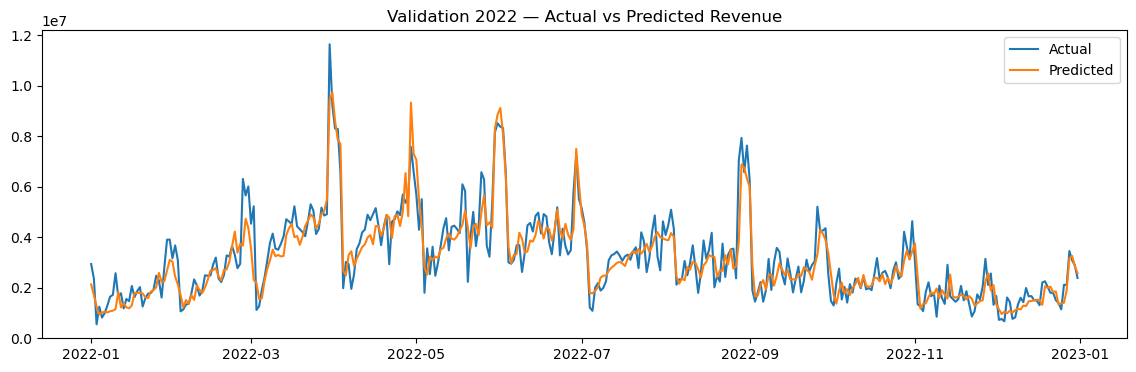

In [29]:
plt.figure(figsize=(14,4))
plt.plot(val_df["Date"], y_val.values, label="Actual")
plt.plot(val_df["Date"], val_pred, label="Predicted")
plt.title("Validation 2022 — Actual vs Predicted Revenue")
plt.legend()
plt.show()

### 18.1. Phân tích lỗi dự báo

Bước này phân tích những ngày mô hình dự báo sai nhiều nhất.

Các chỉ số được tạo:
- `Error`: chênh lệch giữa actual và predicted.
- `Abs_Error`: độ lớn tuyệt đối của sai số.
- `APE`: sai số tuyệt đối theo tỷ lệ phần trăm.

Mục tiêu:
- Xác định các ngày spike mà mô hình chưa bắt tốt.
- Kiểm tra lỗi có tập trung vào một giai đoạn cụ thể không.
- Tìm insight để tiếp tục cải thiện mô hình.

Nếu các lỗi lớn thường rơi vào ngày promotion, cuối năm hoặc traffic bất thường, có thể cần bổ sung thêm event features hoặc cải tiến promotion features.

Top 10 ngày dự báo sai nhiều nhất:


,Date,Revenue,Predicted,Error,Abs_Error,APE
3707,2022-08-28,7051722.27,3.819439e+06,3.232283e+06,3.232283e+06,0.458368
3528,2022-03-02,5221766.09,2.304746e+06,2.917020e+06,2.917020e+06,0.558627
3524,2022-02-26,6304749.98,3.665305e+06,2.639445e+06,2.639445e+06,0.418644
3556,2022-03-30,11643208.73,9.442859e+06,2.200349e+06,2.200349e+06,0.188981
3607,2022-05-20,2226534.20,4.379957e+06,-2.153422e+06,2.153422e+06,0.967163
3736,2022-09-26,5205389.57,3.312448e+06,1.892942e+06,1.892942e+06,0.363650
3578,2022-04-21,2926459.00,4.772316e+06,-1.845857e+06,1.845857e+06,0.630748
3586,2022-04-29,7579535.07,9.329677e+06,-1.750142e+06,1.750142e+06,0.230904
3526,2022-02-28,6007208.86,4.364305e+06,1.642904e+06,1.642904e+06,0.273489
3612,2022-05-25,6573956.43,4.963557e+06,1.610399e+06,1.610399e+06,0.244967


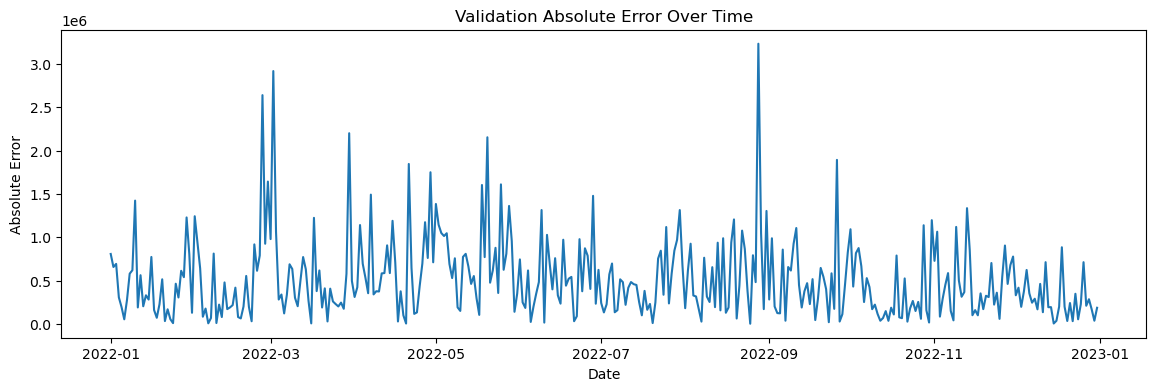

In [30]:
error_df = val_df[["Date", "Revenue"]].copy()
error_df["Predicted"] = val_pred
error_df["Error"] = error_df["Revenue"] - error_df["Predicted"]
error_df["Abs_Error"] = error_df["Error"].abs()
error_df["APE"] = error_df["Abs_Error"] / error_df["Revenue"]

error_df = error_df.sort_values("Abs_Error", ascending=False)

print("Top 10 ngày dự báo sai nhiều nhất:")
display(error_df.head(10))

plt.figure(figsize=(14,4))
plt.plot(error_df.sort_values("Date")["Date"], error_df.sort_values("Date")["Abs_Error"])
plt.title("Validation Absolute Error Over Time")
plt.xlabel("Date")
plt.ylabel("Absolute Error")
plt.show()

### 19. Phân tích tầm quan trọng của feature

Feature importance cho biết mô hình đang dựa nhiều vào những biến nào để đưa ra dự báo.

Vì notebook sử dụng hai mô hình LightGBM, importance được tính riêng cho:
- Model tối ưu MAE.
- Model tối ưu RMSE.

Sau đó, hai giá trị importance được lấy trung bình để có cái nhìn tổng quan.

Mục tiêu:
- Kiểm tra các feature quan trọng có hợp lý về mặt kinh doanh không.
- Phát hiện feature ít giá trị hoặc gây nhiễu.
- Hiểu mô hình đang dựa nhiều vào nhóm tín hiệu nào.

Trong một mô hình tốt, các feature quan trọng thường gồm lag, rolling, calendar, traffic, inventory và business pattern.

In [43]:
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance_mae": model_mae.feature_importances_,
    "importance_rmse": model_rmse.feature_importances_
})

importance["importance_avg"] = (
    importance["importance_mae"] + importance["importance_rmse"]
) / 2

importance = importance.sort_values("importance_avg", ascending=False)

importance.head(10)

,feature,importance_mae,importance_rmse,importance_avg
97,revenue_lag_1,592,1461,1026.5
100,revenue_lag_7,458,913,685.5
101,revenue_lag_14,448,738,593.0
108,revenue_lag_365,397,750,573.5
107,revenue_lag_180,381,606,493.5
98,revenue_lag_2,287,585,436.0
141,revenue_ratio_1_365,287,553,420.0
52,net_item_value,254,514,384.0
103,revenue_lag_28,246,515,380.5
106,revenue_lag_90,254,494,374.0


### 20. Huấn luyện mô hình cuối cùng bằng toàn bộ dữ liệu đến hết năm 2022

Sau khi đã hoàn tất validation trên năm 2022, notebook huấn luyện lại các mô hình cuối cùng bằng toàn bộ dữ liệu lịch sử có sẵn đến hết năm 2022.

Lý do cần bước này:
- Validation dùng năm 2022 để kiểm tra chất lượng mô hình.
- Khi tạo submission cho test 2023–2024, năm 2022 đã trở thành dữ liệu lịch sử gần nhất.
- Train lại với dữ liệu đến hết 2022 giúp mô hình học thêm pattern mới nhất trước khi dự báo test.

Notebook huấn luyện hai nhóm mô hình cuối:
- Final direct model: dự báo từng ngày test độc lập bằng các feature không phụ thuộc vào prediction trước đó.
- Final recursive model: dự báo tuần tự, dùng prediction của ngày trước để tạo lag/rolling cho ngày sau.

Bước này chỉ dùng cho final submission, không dùng để đánh giá validation.

In [32]:
# =========================================================
# Train final direct models using all data up to 2022
# =========================================================

final_direct_train_df = model_df[model_df["year"] <= 2022].copy()

X_final_direct = final_direct_train_df[direct_feature_cols]
y_final_direct = final_direct_train_df[target]

final_direct_model_mae = lgb.LGBMRegressor(
    objective="regression_l1",
    n_estimators=model_mae.best_iteration_ or 1000,
    learning_rate=0.015,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=25,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=0.4,
    random_state=RANDOM_SEED + 101
)

final_direct_model_rmse = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=model_rmse.best_iteration_ or 1000,
    learning_rate=0.015,
    num_leaves=95,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.9,
    colsample_bytree=0.8,
    reg_alpha=0.05,
    reg_lambda=0.5,
    random_state=RANDOM_SEED + 202
)

final_direct_model_mae.fit(X_final_direct, y_final_direct)
final_direct_model_rmse.fit(X_final_direct, y_final_direct)

print("Final direct models trained on data up to 2022.")
print("Final direct training shape:", X_final_direct.shape)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002432 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17033
[LightGBM] [Info] Number of data points in the train set: 3468, number of used features: 95
[LightGBM] [Info] Start training from score 3588932.250000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

In [33]:
# =========================================================
# Train final models using all available historical data up to 2022
# =========================================================

final_train_df = model_df[model_df["year"] <= 2022].copy()

X_final = final_train_df[feature_cols]
y_final = final_train_df[target]

final_model_mae = lgb.LGBMRegressor(
    objective="regression_l1",
    n_estimators=model_mae.best_iteration_ or 1000,
    learning_rate=0.015,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=25,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=0.4,
    random_state=RANDOM_SEED
)

final_model_rmse = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=model_rmse.best_iteration_ or 1000,
    learning_rate=0.015,
    num_leaves=95,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.9,
    colsample_bytree=0.8,
    reg_alpha=0.05,
    reg_lambda=0.5,
    random_state=RANDOM_SEED + 7
)

final_model_mae.fit(X_final, y_final)
final_model_rmse.fit(X_final, y_final)

print("Final models trained on data up to 2022.")
print("Final training shape:", X_final.shape)
print("Date range:", final_train_df["Date"].min(), "to", final_train_df["Date"].max())

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003816 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 29644
[LightGBM] [Info] Number of data points in the train set: 3468, number of used features: 147
[LightGBM] [Info] Start training from score 3588932.250000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

### 21. Dự báo tập test bằng recursive và direct forecasting

Bước này tạo hai hướng dự báo cho tập test:

1. Recursive forecasting:
- Dự báo từng ngày theo thứ tự thời gian.
- Sau khi dự báo một ngày, prediction được thêm vào lịch sử.
- Các ngày sau sử dụng prediction trước đó để tạo lag, rolling, EWM và momentum.
- Cách này tận dụng tốt short-term momentum nhưng có thể tích lũy sai số khi dự báo dài hạn.

2. Direct forecasting:
- Dự báo toàn bộ ngày test độc lập bằng các feature có sẵn trong `sample`.
- Không đưa prediction của ngày trước vào history.
- Cách này ổn định hơn cho horizon dài vì không tích lũy sai số theo chuỗi.

Notebook tạo cả hai bộ prediction để có thể so sánh và lựa chọn bản submission phù hợp nhất.

In [34]:
full_history = sales[["Date", "Revenue"]].copy()
full_history = full_history.sort_values("Date").reset_index(drop=True)

test_pred_rows = []
test_base = sample.sort_values("Date").reset_index(drop=True).copy()

# Nếu bạn đã chọn weight tốt hơn ở validation, sửa 2 dòng này
w_mae = 0.6
w_rmse = 0.4

for i in range(len(test_base)):
    row = test_base.iloc[i].copy()
    current_date = row["Date"]

    temp_hist = full_history.copy()

    def get_lag(days):
        target_date = current_date - pd.Timedelta(days=days)
        value = temp_hist.loc[temp_hist["Date"] == target_date, "Revenue"]
        if len(value) > 0:
            return value.values[0]
        return np.nan

    # Lag features
    for lag in lag_list:
        row[f"revenue_lag_{lag}"] = get_lag(lag)

    hist_before = temp_hist[temp_hist["Date"] < current_date].sort_values("Date")
    shifted_hist = hist_before["Revenue"]

    # Rolling features
    for window in rolling_windows:
        recent_values = shifted_hist.tail(window)

        row[f"revenue_roll_mean_{window}"] = recent_values.mean()
        row[f"revenue_roll_std_{window}"] = recent_values.std()
        row[f"revenue_roll_median_{window}"] = recent_values.median()
        row[f"revenue_roll_min_{window}"] = recent_values.min()
        row[f"revenue_roll_max_{window}"] = recent_values.max()

    # EWM features
    row["revenue_ewm_7"] = shifted_hist.ewm(span=7, adjust=False).mean().iloc[-1]
    row["revenue_ewm_30"] = shifted_hist.ewm(span=30, adjust=False).mean().iloc[-1]

    # Momentum features
    row["revenue_diff_1_7"] = row["revenue_lag_1"] - row["revenue_lag_7"]
    row["revenue_diff_7_30"] = row["revenue_lag_7"] - row["revenue_lag_30"]
    row["revenue_diff_28_365"] = row["revenue_lag_28"] - row["revenue_lag_365"]

    row["revenue_ratio_1_7"] = row["revenue_lag_1"] / (row["revenue_lag_7"] + 1)
    row["revenue_ratio_7_30"] = row["revenue_lag_7"] / (row["revenue_lag_30"] + 1)
    row["revenue_ratio_1_365"] = row["revenue_lag_1"] / (row["revenue_lag_365"] + 1)
    row["revenue_ratio_28_365"] = row["revenue_lag_28"] / (row["revenue_lag_365"] + 1)

    row["revenue_momentum_7_30"] = row["revenue_roll_mean_7"] / (row["revenue_roll_mean_30"] + 1)
    row["revenue_momentum_30_90"] = row["revenue_roll_mean_30"] / (row["revenue_roll_mean_90"] + 1)

    row["revenue_volatility_ratio_7_30"] = row["revenue_roll_std_7"] / (row["revenue_roll_std_30"] + 1)
    row["revenue_volatility_ratio_30_90"] = row["revenue_roll_std_30"] / (row["revenue_roll_std_90"] + 1)

    row["revenue_peak_ratio_7_30"] = row["revenue_roll_max_7"] / (row["revenue_roll_max_30"] + 1)
    row["revenue_floor_ratio_7_30"] = row["revenue_roll_min_7"] / (row["revenue_roll_min_30"] + 1)

    X_test_one = pd.DataFrame([row])[feature_cols]

    for col in feature_cols:
        if X_test_one[col].isnull().any():
            X_test_one[col] = X_test_one[col].fillna(model_df[col].median())

    pred_mae = final_model_mae.predict(X_test_one)[0]
    pred_rmse = final_model_rmse.predict(X_test_one)[0]

    pred = w_mae * pred_mae + w_rmse * pred_rmse
    pred = max(pred, 0)

    test_pred_rows.append({
        "Date": current_date,
        "Revenue": pred
    })

    full_history = pd.concat([
        full_history,
        pd.DataFrame({"Date": [current_date], "Revenue": [pred]})
    ], ignore_index=True)

test_revenue_pred = pd.DataFrame(test_pred_rows)
test_revenue_pred.head()

,Date,Revenue
0,2023-01-01,2.181886e+06
1,2023-01-02,1.821911e+06
2,2023-01-03,1.269929e+06
3,2023-01-04,1.129308e+06
4,2023-01-05,1.136318e+06


In [35]:
# =========================================================
# Direct prediction for test period
# =========================================================

w_direct_mae = 0.4
w_direct_rmse = 0.6

test_direct = sample.sort_values("Date").reset_index(drop=True).copy()

X_test_direct = test_direct[direct_feature_cols].copy()

for col in direct_feature_cols:
    if X_test_direct[col].isnull().any():
        X_test_direct[col] = X_test_direct[col].fillna(model_df[col].median())

direct_pred_mae = final_direct_model_mae.predict(X_test_direct)
direct_pred_rmse = final_direct_model_rmse.predict(X_test_direct)

direct_pred = (
    w_direct_mae * direct_pred_mae
    + w_direct_rmse * direct_pred_rmse
)

direct_pred = np.maximum(direct_pred, 0)

test_revenue_pred_direct = pd.DataFrame({
    "Date": test_direct["Date"],
    "Revenue": direct_pred
})

test_revenue_pred_direct.head()

,Date,Revenue
0,2023-01-01,3.042504e+06
1,2023-01-02,1.775334e+06
2,2023-01-03,1.238662e+06
3,2023-01-04,1.101225e+06
4,2023-01-05,1.216774e+06


### 22. Ước lượng COGS từ Revenue dự báo

Sau khi có Revenue dự báo, notebook ước lượng COGS bằng tỷ lệ lịch sử giữa COGS và Revenue.

Cách làm:
- Tính median của tỷ lệ `COGS / Revenue` trong dữ liệu lịch sử.
- Nhân Revenue dự báo với tỷ lệ này để tạo COGS dự báo.
- Áp dụng ràng buộc để COGS không vượt quá 95% Revenue.

Cách tiếp cận này dựa trên giả định COGS có quan hệ chặt với Revenue. Notebook áp dụng logic này cho các file submission được tạo ở bước sau.

In [36]:
cogs_ratio = (sales["COGS"] / sales["Revenue"]).median()
print("COGS ratio:", cogs_ratio)

test_revenue_pred["COGS"] = test_revenue_pred["Revenue"] * cogs_ratio

# đảm bảo logic COGS < Revenue
test_revenue_pred["COGS"] = np.minimum(
    test_revenue_pred["COGS"],
    test_revenue_pred["Revenue"] * 0.95
)

COGS ratio: 0.8216995431091048


### 23. Tạo file submission

Bước này tạo các file kết quả để nộp.

Notebook tạo hai file chính:
- `submission_recursive.csv`: sử dụng prediction từ recursive forecasting.
- `submission_direct.csv`: sử dụng prediction từ direct forecasting.

Mỗi file submission cần có đúng 3 cột:
- `Date`
- `Revenue`
- `COGS`

Trước khi lưu file, notebook đảm bảo:
- Revenue và COGS không âm.
- COGS không vượt quá Revenue.
- Date được chuyển về định dạng `YYYY-MM-DD`.

Trong các thử nghiệm leaderboard, direct forecasting là hướng có kết quả tốt hơn, nên `submission_direct.csv` là file nên ưu tiên nộp nếu không có thay đổi bổ sung.

In [37]:
submission = sample[["Date"]].merge(test_revenue_pred, on="Date", how="left")

submission["Revenue"] = submission["Revenue"].clip(lower=0)
submission["COGS"] = submission["COGS"].clip(lower=0)

submission["Date"] = submission["Date"].dt.strftime("%Y-%m-%d")

print(submission.head())
print(submission.shape)
print(submission.isnull().sum())

submission.to_csv("submission_recursive.csv", index=False)

         Date       Revenue          COGS
0  2023-01-01  2.181886e+06  1.792855e+06
1  2023-01-02  1.821911e+06  1.497063e+06
2  2023-01-03  1.269929e+06  1.043500e+06
3  2023-01-04  1.129308e+06  9.279519e+05
4  2023-01-05  1.136318e+06  9.337121e+05
(548, 3)
Date       0
Revenue    0
COGS       0
dtype: int64


In [38]:
# =========================================================
# Create direct submission
# =========================================================

submission_direct = sample[["Date"]].merge(
    test_revenue_pred_direct,
    on="Date",
    how="left"
)

cogs_ratio = (sales["COGS"] / sales["Revenue"]).median()

submission_direct["COGS"] = submission_direct["Revenue"] * cogs_ratio
submission_direct["COGS"] = np.minimum(
    submission_direct["COGS"],
    submission_direct["Revenue"] * 0.95
)

submission_direct["Revenue"] = submission_direct["Revenue"].clip(lower=0)
submission_direct["COGS"] = submission_direct["COGS"].clip(lower=0)

submission_direct["Date"] = submission_direct["Date"].dt.strftime("%Y-%m-%d")

submission_direct.to_csv("submission_direct.csv", index=False)

print(submission_direct.head())
print(submission_direct.shape)
print(submission_direct.isnull().sum())
print("Saved:", BASE_DIR / "submission_direct.csv")

         Date       Revenue          COGS
0  2023-01-01  3.042504e+06  2.500024e+06
1  2023-01-02  1.775334e+06  1.458791e+06
2  2023-01-03  1.238662e+06  1.017808e+06
3  2023-01-04  1.101225e+06  9.048762e+05
4  2023-01-05  1.216774e+06  9.998229e+05
(548, 3)
Date       0
Revenue    0
COGS       0
dtype: int64
Saved: C:\Users\Louis\Downloads\datathon-2026-round-1\submission_direct.csv


### 24. Kiểm tra file submission

Trước khi nộp, cần kiểm tra file submission để tránh lỗi format.

Notebook kiểm tra:
- Số dòng submission phải bằng số dòng sample submission.
- Không có giá trị thiếu.
- Cột phải đúng thứ tự: `Date`, `Revenue`, `COGS`.
- Revenue không được âm.
- COGS không được âm.
- COGS phải nhỏ hơn Revenue để đảm bảo logic kinh doanh.

Các câu lệnh `assert` giúp dừng notebook ngay nếu có lỗi, tránh nộp file sai định dạng lên hệ thống. Ở cuối notebook, file `submission_direct.csv` cũng được kiểm tra riêng vì đây là một trong các output chính.

In [39]:
sample_check = pd.read_csv(DATA_DIR / "sample_submission.csv", usecols=["Date"])

assert len(submission) == len(sample_check), "Submission row count does not match sample_submission."
assert submission.isnull().sum().sum() == 0, "Submission contains missing values."
assert list(submission.columns) == ["Date", "Revenue", "COGS"], "Submission columns are incorrect."
assert (submission["Revenue"] >= 0).all(), "Revenue contains negative values."
assert (submission["COGS"] >= 0).all(), "COGS contains negative values."
assert (submission["COGS"] < submission["Revenue"]).all(), "Some COGS values are not lower than Revenue."

print("Submission validation passed.")

Submission validation passed.


In [41]:
# =========================================================
# Validate all generated submissions
# =========================================================

sample_check = pd.read_csv(DATA_DIR / "sample_submission.csv", usecols=["Date"])

submission_files = [
    BASE_DIR / "submission_direct.csv",
]

for file_path in submission_files:
    sub = pd.read_csv(file_path)

    assert len(sub) == len(sample_check), f"Row count mismatch: {file_path.name}"
    assert sub.isnull().sum().sum() == 0, f"Missing values: {file_path.name}"
    assert list(sub.columns) == ["Date", "Revenue", "COGS"], f"Wrong columns: {file_path.name}"
    assert (sub["Revenue"] >= 0).all(), f"Negative Revenue: {file_path.name}"
    assert (sub["COGS"] >= 0).all(), f"Negative COGS: {file_path.name}"
    assert (sub["COGS"] < sub["Revenue"]).all(), f"COGS >= Revenue: {file_path.name}"

    print("Passed:", file_path.name)

Passed: submission_direct.csv


### 25. Tổng kết mô hình dự báo cuối cùng

Notebook này xây dựng một pipeline dự báo Revenue và COGS theo ngày cho giai đoạn test. Toàn bộ quy trình được thiết kế theo hướng kết hợp giữa đặc trưng thời gian, dữ liệu vận hành, hành vi giao dịch và các pattern tài chính trong lịch sử.

Toàn bộ notebook được xây dựng trên bộ dataset đã clean, bao gồm các file dữ liệu gốc đã được chuẩn hóa và hai datamart bổ sung về leakage/profit.

---

#### 1. Mục tiêu bài toán

Mục tiêu chính của mô hình là dự báo:

- `Revenue`: doanh thu theo ngày.
- `COGS`: giá vốn hàng bán theo ngày.

File submission cuối cùng cần có đúng ba cột:

- `Date`
- `Revenue`
- `COGS`

Trong đó, `Date` được lấy từ `sample_submission.csv`, còn `Revenue` và `COGS` là giá trị dự báo.

---

#### 2. Nguồn dữ liệu được sử dụng

Notebook sử dụng bộ dữ liệu đã được clean trước khi đưa vào mô hình. Các bước làm sạch bao gồm chuẩn hóa schema, xử lý giá trị bất thường, điều chỉnh các cột tài chính và tạo thêm các datamart phục vụ phân tích leakage/profit.

Các nhóm dữ liệu chính gồm:

- `sales.csv`: dữ liệu mục tiêu lịch sử gồm Revenue và COGS theo ngày.
- `web_traffic.csv`: phản ánh nhu cầu truy cập và mức độ quan tâm của khách hàng.
- `inventory.csv`: phản ánh tình trạng tồn kho, khả năng đáp ứng hàng hóa và tốc độ bán hàng.
- `orders.csv` và `order_items.csv`: mô tả hành vi đơn hàng, số lượng sản phẩm, giá trị đơn và discount.
- `promotions.csv`: mô tả các chương trình khuyến mãi.
- `returns.csv` và `reviews.csv`: phản ánh tín hiệu hậu mua hàng như hoàn trả, refund và đánh giá khách hàng.
- `leakage_datamart.csv`: tổng hợp các đơn hàng có khả năng gây thất thoát như cancelled hoặc returned.
- `profit_datamart.csv`: tổng hợp các đơn hàng delivered mang lại doanh thu, COGS và lợi nhuận thực tế.

Các nguồn dữ liệu này được xử lý thành feature ở cấp độ ngày hoặc pattern lịch sử theo `month` và `day`, giúp mô hình học được cả yếu tố vận hành, giao dịch, tài chính và mùa vụ.

---

#### 3. Feature engineering

Pipeline tạo nhiều nhóm feature khác nhau:

- Calendar features: năm, tháng, ngày, thứ trong tuần, cuối tuần, đầu/cuối tháng và các biến chu kỳ.
- Traffic features: sessions, unique visitors, page views, bounce rate, session duration và các chỉ số tương tác mở rộng.
- Inventory features: tồn kho, hàng nhập, hàng bán, fill rate, sell-through rate và các chỉ số hiệu quả cung ứng.
- Business pattern features: pattern lịch sử của đơn hàng, khách hàng, promotion, return và review.
- Datamart pattern features: pattern lịch sử về GMV, realized revenue, actual COGS, net profit, refund, lost GMV và financial loss.
- Lag features: Revenue của các mốc quá khứ như 1 ngày, 7 ngày, 30 ngày, 90 ngày, 180 ngày và 365 ngày trước.
- Rolling features: trung bình, độ lệch chuẩn, min, max và median trong các cửa sổ thời gian.
- EWM features: trung bình động có trọng số, ưu tiên các quan sát gần hiện tại.
- Momentum features: chênh lệch, tỷ lệ và xu hướng giữa các mốc Revenue khác nhau.

Các feature này giúp mô hình học được cả yếu tố mùa vụ, xu hướng ngắn hạn, chu kỳ dài hạn, biến động kinh doanh và tín hiệu tài chính.

---

#### 4. Chiến lược validation

Dữ liệu được chia theo thời gian thay vì chia ngẫu nhiên:

- Train: dữ liệu từ 2012 đến hết 2021.
- Validation: dữ liệu năm 2022.

Cách chia này mô phỏng tình huống thực tế: dùng dữ liệu quá khứ để dự báo tương lai.

Validation được dùng để đánh giá mô hình bằng các chỉ số:

- MAE: sai số tuyệt đối trung bình.
- RMSE: phạt mạnh các lỗi lớn.
- R²: mức độ mô hình giải thích được biến động của Revenue.

---

#### 5. Mô hình sử dụng

Notebook sử dụng LightGBM vì mô hình này phù hợp với dữ liệu dạng bảng, nhiều feature và quan hệ phi tuyến.

Hai mô hình chính được huấn luyện:

- Model tối ưu MAE (`regression_l1`): tập trung giảm sai số tuyệt đối trung bình.
- Model tối ưu RMSE (`regression`): nhạy hơn với các lỗi lớn và giúp kiểm soát spike.

Prediction từ hai mô hình được kết hợp bằng weighted average để cân bằng giữa độ ổn định và khả năng xử lý biến động lớn.

---

#### 6. Hai hướng dự báo: recursive và direct

Notebook tạo hai hướng dự báo cho tập test:

**Recursive forecasting**

- Dự báo từng ngày theo thứ tự thời gian.
- Sau khi dự báo một ngày, prediction được thêm vào lịch sử.
- Các ngày sau sử dụng prediction trước đó để tạo lag, rolling, EWM và momentum.
- Ưu điểm là tận dụng tốt short-term momentum.
- Nhược điểm là có thể tích lũy sai số khi dự báo dài hạn.

**Direct forecasting**

- Dự báo từng ngày test độc lập bằng các feature có sẵn.
- Không đưa prediction của ngày trước vào history.
- Ưu điểm là ổn định hơn với horizon dài vì không tích lũy sai số theo chuỗi.
- Trong quá trình thử nghiệm leaderboard, direct forecasting cho kết quả tốt hơn nên được ưu tiên làm file submission chính.

---

#### 7. Huấn luyện mô hình cuối cùng

Sau khi validation được sử dụng để đánh giá và lựa chọn hướng mô hình, notebook huấn luyện lại mô hình cuối cùng bằng toàn bộ dữ liệu lịch sử đến hết năm 2022.

Lý do:

- Năm 2022 là dữ liệu lịch sử gần nhất trước tập test 2023–2024.
- Việc sử dụng thêm năm 2022 giúp mô hình học được pattern mới hơn.
- Mô hình cuối cùng tận dụng tối đa dữ liệu có sẵn trước khi dự báo test.

---

#### 8. Ước lượng COGS

Sau khi có Revenue dự báo, COGS được ước lượng dựa trên tỷ lệ lịch sử giữa COGS và Revenue.

Cách làm:

- Tính median của tỷ lệ `COGS / Revenue`.
- Nhân Revenue dự báo với tỷ lệ này để tạo COGS dự báo.
- Ràng buộc COGS không vượt quá 95% Revenue để đảm bảo logic kinh doanh.

Cách tiếp cận này đơn giản nhưng phù hợp vì COGS có quan hệ chặt với Revenue.

---

#### 9. File submission

Notebook tạo các file submission với đúng định dạng yêu cầu. Trong đó, file direct forecasting được ưu tiên nộp vì cho kết quả leaderboard tốt hơn trong quá trình thử nghiệm.

Trước khi nộp, file submission được kiểm tra:

- Đúng số dòng so với sample submission.
- Không có missing value.
- Đúng thứ tự cột.
- Revenue và COGS không âm.
- COGS nhỏ hơn Revenue.

---

#### 10. Kết luận

Pipeline final sử dụng bộ dữ liệu đã được clean, kết hợp dữ liệu lịch sử, dữ liệu vận hành, dữ liệu giao dịch và tín hiệu tài chính để dự báo Revenue và COGS theo ngày.

Mô hình không chỉ dựa vào xu hướng doanh thu quá khứ mà còn sử dụng thêm các pattern về traffic, inventory, promotion, return, review, leakage và profit.

Hướng direct forecasting được chọn làm submission chính vì có khả năng dự báo ổn định hơn cho giai đoạn test dài 2023–2024. Đây là lựa chọn phù hợp khi dự báo nhiều bước trong tương lai và cần hạn chế sai số tích lũy từ recursive forecasting.